# Regression pipeline for predicting Oral Temperature from Infrared Thermography data

0. Import all necessary modules

In [269]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, PolynomialFeatures, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso,
    ElasticNet
)

from sklearn.tree import DecisionTreeRegressor

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import (
    GridSearchCV,
    GroupShuffleSplit,
    GroupKFold,
    cross_val_score
)

from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error
)

from sklearn.decomposition import PCA

1. Load the dataset from the excel sheet. The excel sheet has 4 sheets corresponding to 4 different trial of the experiment in a 10 minutes interval. Each trial is a `pandas.Dataframe` , and the variable `df_trials -> [pandas.Dataframe]` is a 4 length list storing each trial. We observe that the main header is in the row 3.

In [270]:
df=[pd.read_excel('../datasets/ICI.xlsx',sheet_name='Round 1',header=2),
     pd.read_excel('../datasets/ICI.xlsx',sheet_name='Round 2',header=2),
     pd.read_excel('../datasets/ICI.xlsx',sheet_name='Round 3',header=2),
     pd.read_excel('../datasets/ICI.xlsx',sheet_name='Round 4',header=2)]
df[0].head(10)

,SubjectID,T_offset1,Max1R13_1,Max1L13_1,aveAllR13_1,aveAllL13_1,T_RC1,T_RC_Dry1,T_RC_Wet1,T_RC_Max1,...,aveOralM,Gender,Age,Ethnicity,T_atm,Humidity,Distance,Cosmetics,Time,Date
0,161117-1,-0.27,34.94,35.48,34.05,34.74,34.92,34.92,34.71,34.94,...,36.59,Male,41-50,White,24.0,28.0,0.8,NaN,12:43:46,2017-11-16
1,161117-2,-0.21,33.56,34.93,33.23,34.14,34.80,33.97,34.80,34.89,...,37.19,Female,31-40,Black or African-American,24.0,26.0,0.8,NaN,15:22:48,2017-11-16
2,161117-3,-0.28,35.91,35.60,35.46,34.71,35.83,35.83,35.50,35.91,...,37.34,Female,21-30,White,24.0,26.0,0.8,NaN,15:52:56,2017-11-16
3,161117-4,-0.32,35.25,35.46,33.78,33.88,35.24,35.20,35.22,35.25,...,37.09,Female,21-30,Black or African-American,24.0,27.0,0.8,NaN,16:07:53,2017-11-16
4,161117-5,-0.52,35.57,35.78,34.38,35.27,35.60,35.54,35.60,35.66,...,37.04,Male,18-20,White,24.0,27.0,0.8,NaN,16:28:06,2017-11-16
5,161117-6,-0.26,34.87,35.11,34.10,34.62,34.88,34.88,34.75,34.89,...,36.99,Female,21-30,White,24.0,26.0,0.8,NaN,16:43:28,2017-11-16
6,161118-1,-0.14,35.01,35.46,34.48,34.54,34.98,34.98,34.72,35.01,...,36.59,Male,21-30,White,24.0,31.0,0.8,NaN,12:11:01,2018-11-16
7,161118-2,-0.79,34.54,34.52,33.49,33.31,34.57,34.57,34.28,34.67,...,36.49,Female,18-20,White,25.0,30.0,0.8,NaN,12:40:41,2018-11-16
8,161118-3,-0.20,35.17,35.44,33.59,33.99,35.56,34.87,35.56,35.58,...,36.99,Female,18-20,White,25.0,30.0,0.8,NaN,14:27:47,2018-11-16
9,161118-4,-0.32,35.22,35.36,33.62,34.47,35.30,35.15,35.30,35.31,...,36.59,Female,18-20,Asian,25.0,30.0,0.8,NaN,14:44:13,2018-11-16


2. Rename the columns in all the dataframe to a more legible name.

In [271]:
base_mapping = {
    'T_offset': 'Calibration_Offset',
    'Max1R13_': 'Right_Inner_Eye_Max',
    'Max1L13_': 'Left_Inner_Eye_Max',
    'aveAllR13_': 'Right_Inner_Eye_Avg',
    'aveAllL13_': 'Left_Inner_Eye_Avg',
    'T_RC': 'Right_Eye_Avg',
    'T_RC_Dry': 'Right_Eye_Skin',
    'T_RC_Wet': 'Right_Tear_Duct',
    'T_RC_Max': 'Right_Eye_Max',
    'T_LC': 'Left_Eye_Avg',
    'T_LC_Dry': 'Left_Eye_Skin',
    'T_LC_Wet': 'Left_Tear_Duct',
    'T_LC_Max': 'Left_Eye_Max',
    'RCC': 'Right_Eye_Center',
    'LCC': 'Left_Eye_Center',
    'canthiMax': 'Hottest_Eye_Overall',
    'canthi4Max': 'Hottest_Eye_4Points',
    'T_FHCC': 'Forehead_Center',
    'T_FHRC': 'Forehead_Right',
    'T_FHLC': 'Forehead_Left',
    'T_FHBC': 'Forehead_Bottom',
    'T_FHTC': 'Forehead_Top',
    'T_FH_Max': 'Forehead_Overall_Max',
    'T_FHC_Max': 'Forehead_Center_Max',
    'T_Max': 'Face_Overall_Max',
    'T_OR': 'Mouth_Avg',
    'T_OR_Max': 'Mouth_Max'
}
full_mapping = {
    'SubjectID': 'Subject_ID',
    'aveOralF': 'True_Core_Temp_Fast',
    'aveOralM': 'True_Core_Temp_Slow',
    'T_atm': 'Room_Temperature',
    'Humidity': 'Room_Humidity',
    'Distance': 'Camera_Distance_m',
    'Cosmetics': 'Wearing_Makeup'
}
for old_base, new_base in base_mapping.items():
    for round_num in range(1, 5):
        old_col_name = f"{old_base}{round_num}" if not old_base.endswith('_') else f"{old_base}{round_num}"
        new_col_name = f"{new_base}_R{round_num}" 
        full_mapping[old_col_name] = new_col_name

for i in range(len(df)):
    df[i].rename(columns=full_mapping, inplace=True)
df[0].head()

,Subject_ID,Calibration_Offset_R1,Right_Inner_Eye_Max_R1,Left_Inner_Eye_Max_R1,Right_Inner_Eye_Avg_R1,Left_Inner_Eye_Avg_R1,Right_Eye_Avg_R1,Right_Eye_Skin_R1,Right_Tear_Duct_R1,Right_Eye_Max_R1,...,True_Core_Temp_Slow,Gender,Age,Ethnicity,Room_Temperature,Room_Humidity,Camera_Distance_m,Wearing_Makeup,Time,Date
0,161117-1,-0.27,34.94,35.48,34.05,34.74,34.92,34.92,34.71,34.94,...,36.59,Male,41-50,White,24.0,28.0,0.8,NaN,12:43:46,2017-11-16
1,161117-2,-0.21,33.56,34.93,33.23,34.14,34.80,33.97,34.80,34.89,...,37.19,Female,31-40,Black or African-American,24.0,26.0,0.8,NaN,15:22:48,2017-11-16
2,161117-3,-0.28,35.91,35.60,35.46,34.71,35.83,35.83,35.50,35.91,...,37.34,Female,21-30,White,24.0,26.0,0.8,NaN,15:52:56,2017-11-16
3,161117-4,-0.32,35.25,35.46,33.78,33.88,35.24,35.20,35.22,35.25,...,37.09,Female,21-30,Black or African-American,24.0,27.0,0.8,NaN,16:07:53,2017-11-16
4,161117-5,-0.52,35.57,35.78,34.38,35.27,35.60,35.54,35.60,35.66,...,37.04,Male,18-20,White,24.0,27.0,0.8,NaN,16:28:06,2017-11-16


3. List all the column names in the dataframe

In [272]:
print(df[1].columns.tolist())


['Subject_ID', 'Calibration_Offset_R2', 'Right_Inner_Eye_Max_R2', 'Left_Inner_Eye_Max_R2', 'Right_Inner_Eye_Avg_R2', 'Left_Inner_Eye_Avg_R2', 'Right_Eye_Avg_R2', 'Right_Eye_Skin_R2', 'Right_Tear_Duct_R2', 'Right_Eye_Max_R2', 'Left_Eye_Avg_R2', 'Left_Eye_Skin_R2', 'Left_Tear_Duct_R2', 'Left_Eye_Max_R2', 'Right_Eye_Center_R2', 'Left_Eye_Center_R2', 'Hottest_Eye_Overall_R2', 'Hottest_Eye_4Points_R2', 'Forehead_Center_R2', 'Forehead_Right_R2', 'Forehead_Left_R2', 'Forehead_Bottom_R2', 'Forehead_Top_R2', 'Forehead_Overall_Max_R2', 'Forehead_Center_Max_R2', 'Face_Overall_Max_R2', 'Mouth_Avg_R2', 'Mouth_Max_R2', 'True_Core_Temp_Fast', 'True_Core_Temp_Slow', 'Gender', 'Age', 'Ethnicity', 'Room_Temperature', 'Room_Humidity', 'Camera_Distance_m', 'Wearing_Makeup', 'Time', 'Date']


In [273]:
df[0].info()


<class 'pandas.DataFrame'>
RangeIndex: 1009 entries, 0 to 1008
Data columns (total 39 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Subject_ID               1009 non-null   str           
 1   Calibration_Offset_R1    955 non-null    float64       
 2   Right_Inner_Eye_Max_R1   956 non-null    float64       
 3   Left_Inner_Eye_Max_R1    956 non-null    float64       
 4   Right_Inner_Eye_Avg_R1   956 non-null    float64       
 5   Left_Inner_Eye_Avg_R1    956 non-null    float64       
 6   Right_Eye_Avg_R1         955 non-null    float64       
 7   Right_Eye_Skin_R1        955 non-null    float64       
 8   Right_Tear_Duct_R1       955 non-null    float64       
 9   Right_Eye_Max_R1         955 non-null    float64       
 10  Left_Eye_Avg_R1          955 non-null    float64       
 11  Left_Eye_Skin_R1         955 non-null    float64       
 12  Left_Tear_Duct_R1        955 non-null    floa

4. Identify and print numerical column, categorical column (ordinal, nominal).

In [274]:
df[0].dtypes

Subject_ID                            str
Calibration_Offset_R1             float64
Right_Inner_Eye_Max_R1            float64
Left_Inner_Eye_Max_R1             float64
Right_Inner_Eye_Avg_R1            float64
Left_Inner_Eye_Avg_R1             float64
Right_Eye_Avg_R1                  float64
Right_Eye_Skin_R1                 float64
Right_Tear_Duct_R1                float64
Right_Eye_Max_R1                  float64
Left_Eye_Avg_R1                   float64
Left_Eye_Skin_R1                  float64
Left_Tear_Duct_R1                 float64
Left_Eye_Max_R1                   float64
Right_Eye_Center_R1               float64
Left_Eye_Center_R1                float64
Hottest_Eye_Overall_R1            float64
Hottest_Eye_4Points_R1            float64
Forehead_Center_R1                float64
Forehead_Right_R1                 float64
Forehead_Left_R1                  float64
Forehead_Bottom_R1                float64
Forehead_Top_R1                   float64
Forehead_Overall_Max_R1           

In [275]:
nominal_cols = ['Subject_ID', 'Gender', 'Ethnicity', 'Wearing_Makeup']
ordinal_cols = ['Age']
datetime_cols = ['Time', 'Date']
all_cols = df[3].columns.tolist()
exclude_cols = nominal_cols + ordinal_cols + datetime_cols
numerical_cols = [col for col in all_cols if col not in exclude_cols]
print(f" NOMINAL COLUMNS ({len(nominal_cols)})")
print(nominal_cols)

print(f"\nORDINAL COLUMNS ({len(ordinal_cols)})")
print(ordinal_cols)

print(f"\n NUMERICAL COLUMNS ({len(numerical_cols)})")
print(numerical_cols)

 NOMINAL COLUMNS (4)
['Subject_ID', 'Gender', 'Ethnicity', 'Wearing_Makeup']

ORDINAL COLUMNS (1)
['Age']

 NUMERICAL COLUMNS (32)
['Calibration_Offset_R4', 'Right_Inner_Eye_Max_R4', 'Left_Inner_Eye_Max_R4', 'Right_Inner_Eye_Avg_R4', 'Left_Inner_Eye_Avg_R4', 'Right_Eye_Avg_R4', 'Right_Eye_Skin_R4', 'Right_Tear_Duct_R4', 'Right_Eye_Max_R4', 'Left_Eye_Avg_R4', 'Left_Eye_Skin_R4', 'Left_Tear_Duct_R4', 'Left_Eye_Max_R4', 'Right_Eye_Center_R4', 'Left_Eye_Center_R4', 'Hottest_Eye_Overall_R4', 'Hottest_Eye_4Points_R4', 'Forehead_Center_R4', 'Forehead_Right_R4', 'Forehead_Left_R4', 'Forehead_Bottom_R4', 'Forehead_Top_R4', 'Forehead_Overall_Max_R4', 'Forehead_Center_Max_R4', 'Face_Overall_Max_R4', 'Mouth_Avg_R4', 'Mouth_Max_R4', 'True_Core_Temp_Fast', 'True_Core_Temp_Slow', 'Room_Temperature', 'Room_Humidity', 'Camera_Distance_m']


Here we prematurelt drop NAs because I observe in the sheet that there are missing rows, which can be dropped without imputations

In [276]:
df[0].isna().sum()

Subject_ID                  0
Calibration_Offset_R1      54
Right_Inner_Eye_Max_R1     53
Left_Inner_Eye_Max_R1      53
Right_Inner_Eye_Avg_R1     53
Left_Inner_Eye_Avg_R1      53
Right_Eye_Avg_R1           54
Right_Eye_Skin_R1          54
Right_Tear_Duct_R1         54
Right_Eye_Max_R1           54
Left_Eye_Avg_R1            54
Left_Eye_Skin_R1           54
Left_Tear_Duct_R1          54
Left_Eye_Max_R1            54
Right_Eye_Center_R1        55
Left_Eye_Center_R1         55
Hottest_Eye_Overall_R1     54
Hottest_Eye_4Points_R1     55
Forehead_Center_R1         54
Forehead_Right_R1          54
Forehead_Left_R1           54
Forehead_Bottom_R1         54
Forehead_Top_R1            54
Forehead_Overall_Max_R1    54
Forehead_Center_Max_R1     54
Face_Overall_Max_R1        54
Mouth_Avg_R1               54
Mouth_Max_R1               54
True_Core_Temp_Fast         0
True_Core_Temp_Slow         0
Gender                      0
Age                         0
Ethnicity                   0
Room_Tempe

In [277]:
# Check for duplicate rows
for i in range(len(df)):
    print(f"Round {i+1} duplicates:", df[i].duplicated().sum())

Round 1 duplicates: 0
Round 2 duplicates: 0
Round 3 duplicates: 0
Round 4 duplicates: 0


### Visualizations

We observe above that out of 1009 records, only around 50 is NA. which is like 0.5% of the data. So we shall drop it

In [278]:
for i in range(len(df)):
    df[i].dropna(inplace=True)

Count of Male vs Female

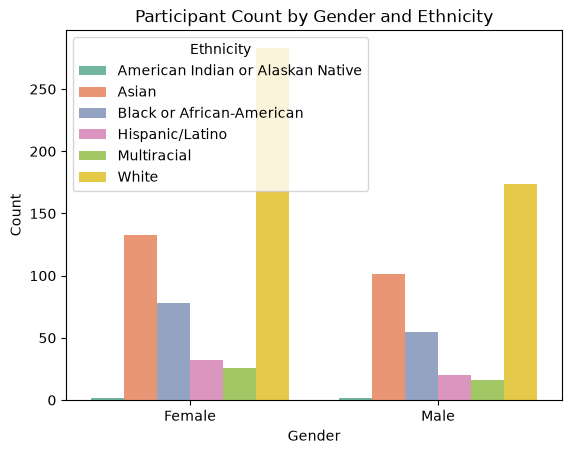

Gender
Female    554
Male      368
Name: count, dtype: int64


In [279]:
male_female_counts = (
    df[0].loc[df[0]["Gender"].notna(), ["Gender", "Subject_ID"]]
    .groupby("Gender")
    .count()
    .rename(columns={"Subject_ID": "Count"})
)

gender_ethnicity_counts = (
    df[0][df[0]["Gender"].notnull() & df[0]["Ethnicity"].notnull()]
    [["Subject_ID", "Gender", "Ethnicity"]]
    .groupby(["Gender", "Ethnicity"], as_index=False)
    .count()
    .rename(columns={"Subject_ID": "Count"})
)

plt.figure()

sns.barplot(
    data=gender_ethnicity_counts,
    x="Gender",
    y="Count",
    hue="Ethnicity",
    palette="Set2"
)

plt.title("Participant Count by Gender and Ethnicity")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.legend(title="Ethnicity")
plt.show()
male_female_counts = df[0]["Gender"].value_counts()

print(male_female_counts)

The dataset contains more female observations than male observations. The distribution across ethnic groups is also uneven, with White and Asian participants contributing a larger number of observations than the remaining categories. Therefore, the categorical variables should be retained during preprocessing, while keeping the imbalance in the dataset in mind when interpreting the regression results.

5. For the first trial, we will do the following visualizations

    - Scatterplot between all features in the dataset
    - Boxplot of all features to identify outliers
    - Historgram to identify the shape of all the features
    - Heatmap to idenitfy correlations between all the features.

a) Boxplot

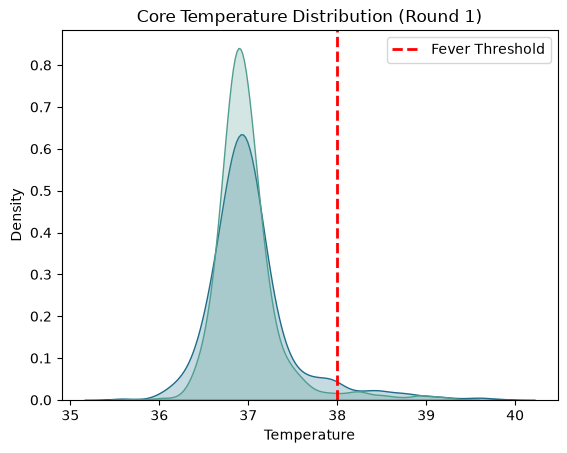

In [280]:
data = df[0].copy()

melted_data = data[['True_Core_Temp_Fast', 'True_Core_Temp_Slow']].melt(
    var_name='Sensor Type',
    value_name='Temperature'
)

plt.figure()

sns.kdeplot(
    data=melted_data,
    x='Temperature',
    hue='Sensor Type',
    fill=True,
    palette='crest'
)

fever_threshold = 38.0

plt.axvline(
    x=fever_threshold,
    color='red',
    linestyle='--',
    linewidth=2,
    label='Fever Threshold'
)

plt.title('Core Temperature Distribution (Round 1)')
plt.xlabel('Temperature')
plt.legend()

plt.show()

The KDE plot compares the distributions of the Fast and Slow core-temperature measurements in Round 1. The 38°C reference line is included to identify observations above the selected temperature threshold.

Both measurements are concentrated around the normal core-temperature range and show similar distribution patterns. A smaller number of observations extend beyond the 38°C reference threshold, which can be examined further during outlier analysis.

C:\Users\navee\AppData\Local\Temp\ipykernel_6896\4013461676.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=melted, x="Feature", y="Value", palette="Set3", ax=ax)
C:\Users\navee\AppData\Local\Temp\ipykernel_6896\4013461676.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=melted, x="Feature", y="Value", palette="Set3", ax=ax)
C:\Users\navee\AppData\Local\Temp\ipykernel_6896\4013461676.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=melted, x="Feature", y="Value", palette="Set3", ax=ax)
C:\Users\navee\AppData\Local

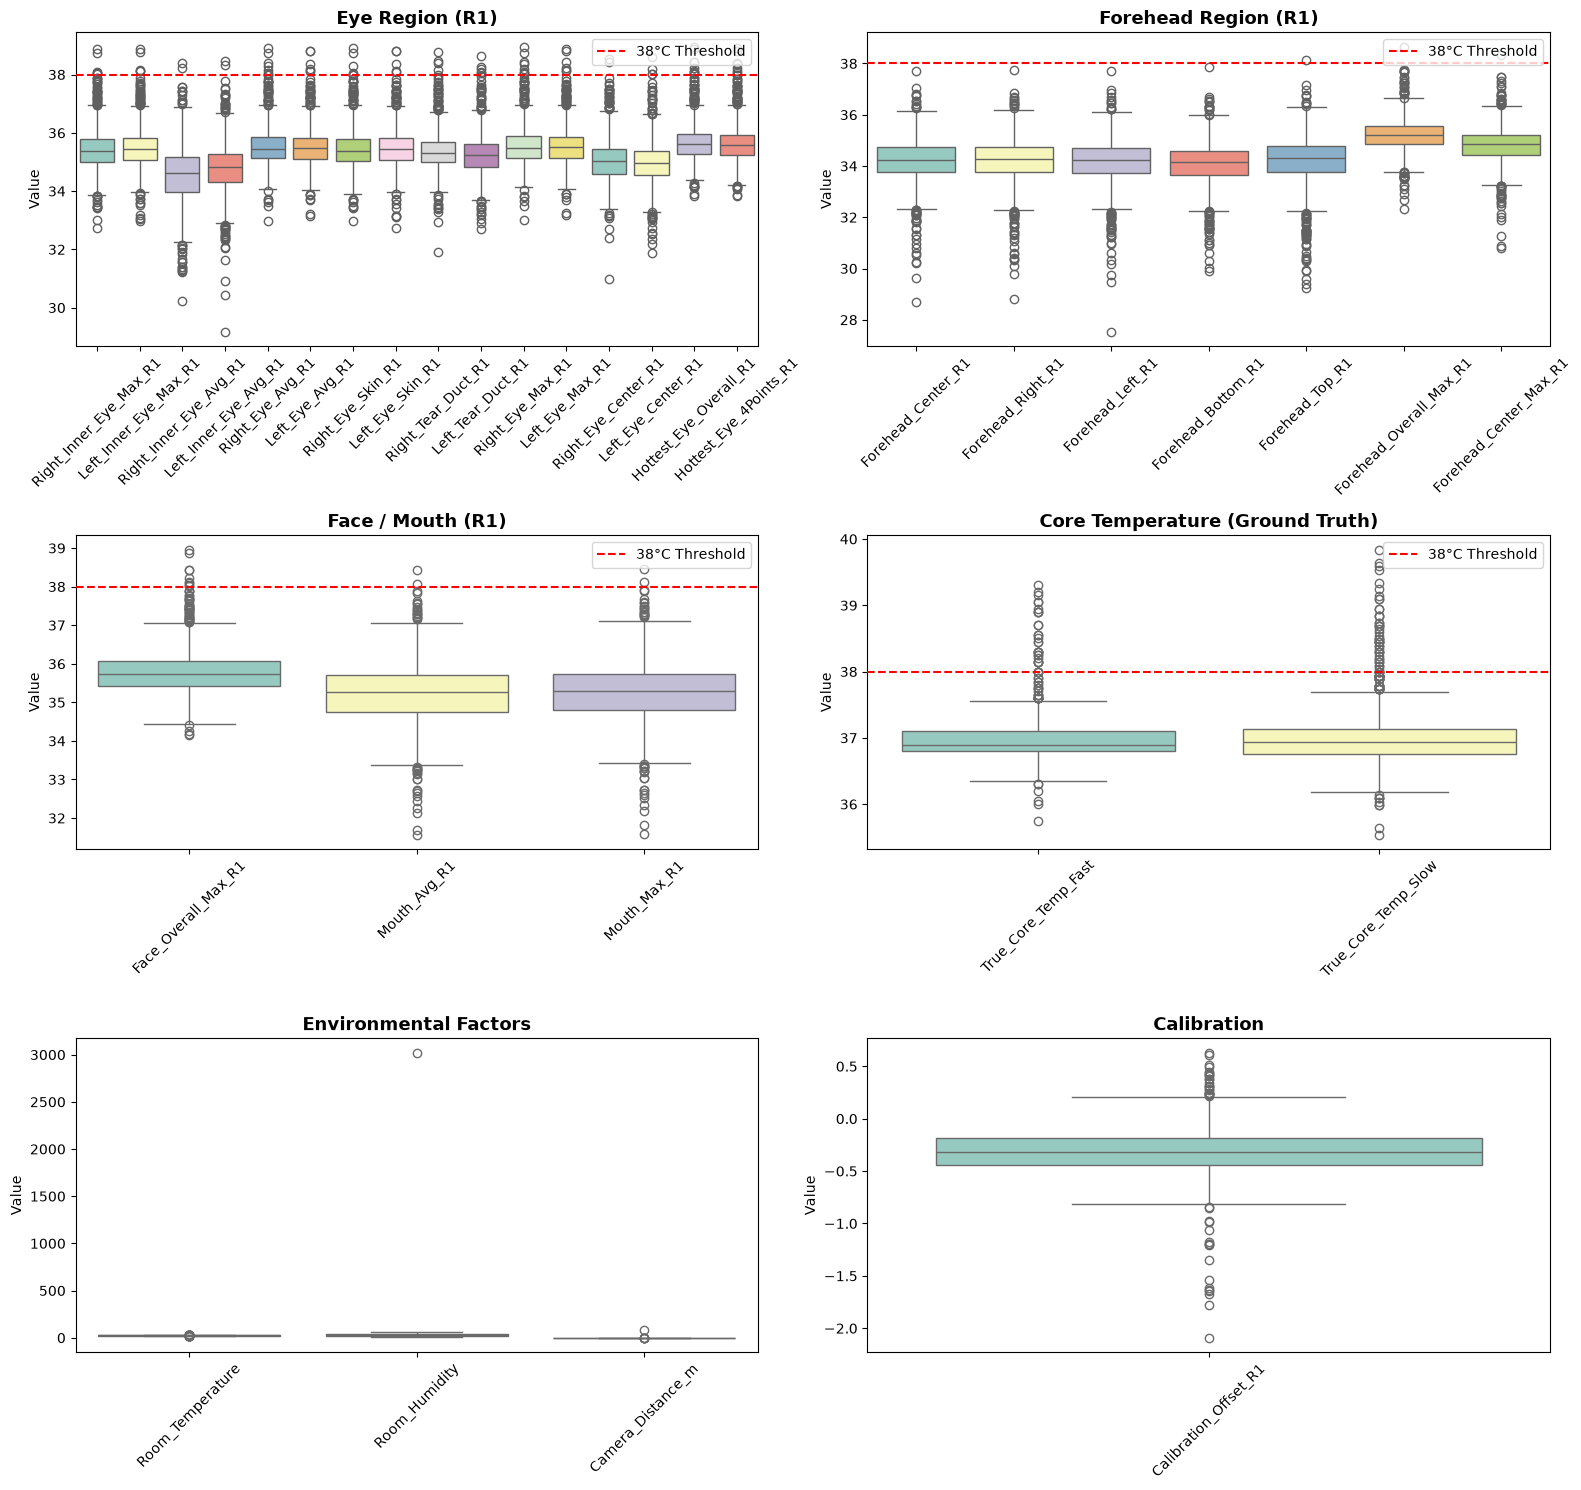

In [281]:
data = df[0].copy()

feature_groups = {
    "Eye Region (R1)": [
        'Right_Inner_Eye_Max_R1', 'Left_Inner_Eye_Max_R1',
        'Right_Inner_Eye_Avg_R1', 'Left_Inner_Eye_Avg_R1',
        'Right_Eye_Avg_R1', 'Left_Eye_Avg_R1',
        'Right_Eye_Skin_R1', 'Left_Eye_Skin_R1',
        'Right_Tear_Duct_R1', 'Left_Tear_Duct_R1',
        'Right_Eye_Max_R1', 'Left_Eye_Max_R1',
        'Right_Eye_Center_R1', 'Left_Eye_Center_R1',
        'Hottest_Eye_Overall_R1', 'Hottest_Eye_4Points_R1'
    ],
    "Forehead Region (R1)": [
        'Forehead_Center_R1', 'Forehead_Right_R1', 'Forehead_Left_R1',
        'Forehead_Bottom_R1', 'Forehead_Top_R1',
        'Forehead_Overall_Max_R1', 'Forehead_Center_Max_R1'
    ],
    "Face / Mouth (R1)": [
        'Face_Overall_Max_R1', 'Mouth_Avg_R1', 'Mouth_Max_R1'
    ],
    "Core Temperature (Ground Truth)": [
        'True_Core_Temp_Fast', 'True_Core_Temp_Slow'
    ],
    "Environmental Factors": [
        'Room_Temperature', 'Room_Humidity', 'Camera_Distance_m'
    ],
    "Calibration": [
        'Calibration_Offset_R1'
    ]
}

n_groups = len(feature_groups)
n_cols = 2
n_rows = (n_groups + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5 * n_rows))
axes = axes.flatten()

for ax, (group_name, cols) in zip(axes, feature_groups.items()):
    melted = data[cols].melt(var_name="Feature", value_name="Value")
    sns.boxplot(data=melted, x="Feature", y="Value", palette="Set3", ax=ax)
    if group_name not in ["Calibration", "Environmental Factors"]:
        ax.axhline(
            y=38.0, 
            color='red', 
            linestyle='--', 
            linewidth=1.5, 
            zorder=5, 
            label='38°C Threshold'
        )
        ax.legend(loc='upper right') 
    
    ax.set_title(group_name, fontsize=13, fontweight="bold")
    ax.set_xlabel("")
    ax.tick_params(axis='x', rotation=45)

for ax in axes[len(feature_groups):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

The features are divided into six meaningful regions: Eye Region, Forehead Region, Face/Mouth, Core Temperature, Environmental Factors, and Calibration. Outliers below the fever range should not automatically be removed because they may represent genuine lower thermal readings caused by facial location, environmental conditions, or natural measurement variation. Removing them could eliminate valid information and reduce the model's ability to generalize to different temperature conditions.

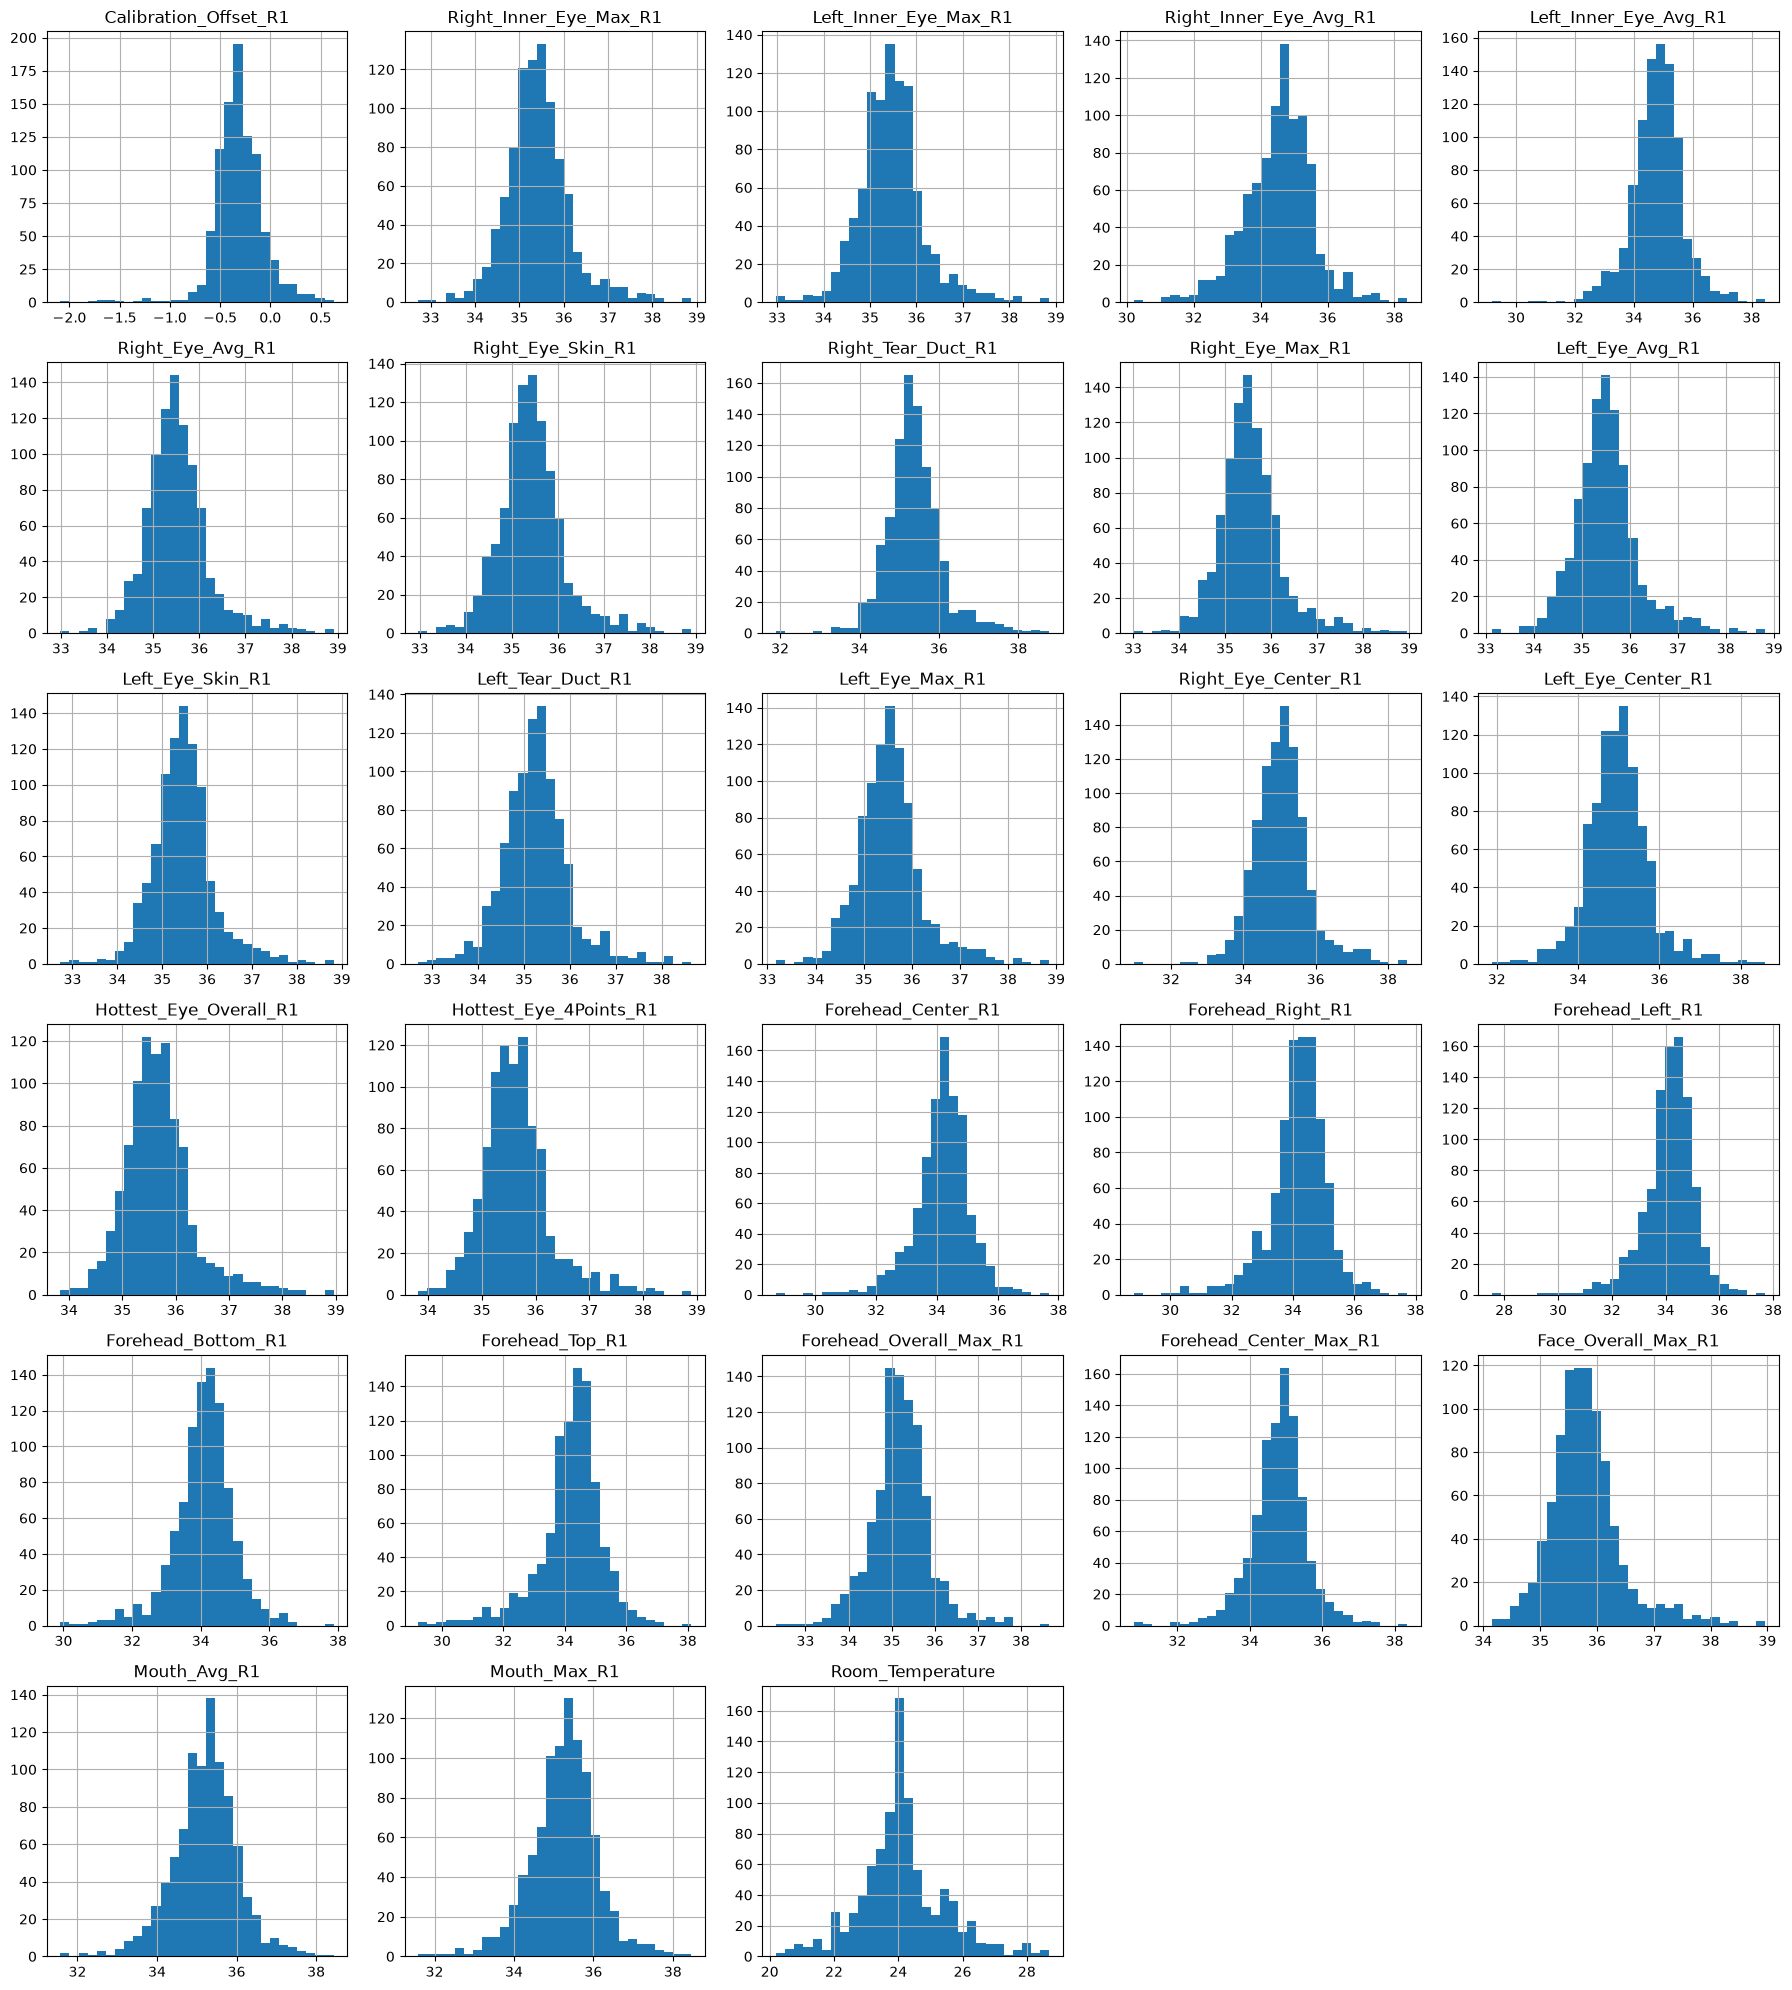

In [282]:

data = df[0].copy()

numeric_cols = data.select_dtypes(include=np.number).columns

feature_cols_eda = [
    col for col in numeric_cols
    if col not in ['True_Core_Temp_Fast', 'True_Core_Temp_Slow','Wearing_Makeup', 'Room_Humidity', 'Camera_Distance_m']
]

data[feature_cols_eda].hist(
    figsize=(18, 20),
    bins=30
)

plt.tight_layout()
plt.show()

 Most of the thermal features show concentrated distributions around their typical temperature ranges, with some features displaying skewness and extreme observations. The distributions help identify the general shape and spread of the features before applying further preprocessing and outlier handling.

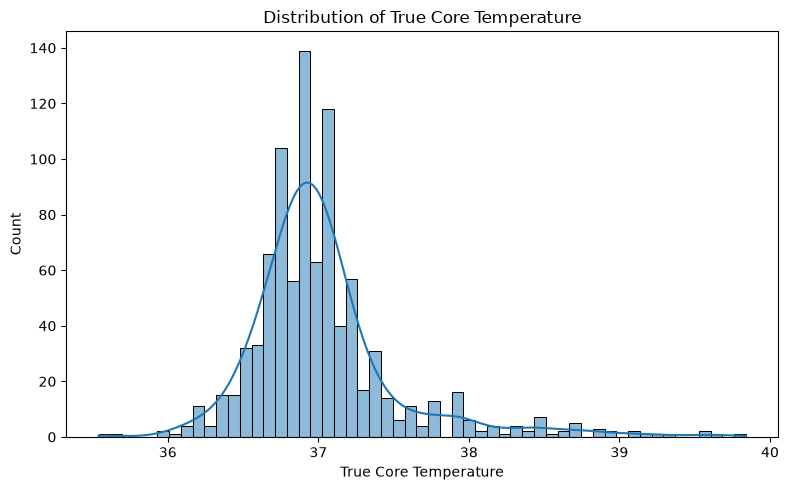

In [283]:
# Target distribution

plt.figure(figsize=(8, 5))

sns.histplot(
    data=data,
    x='True_Core_Temp_Slow',
    kde=True
)

plt.title("Distribution of True Core Temperature")
plt.xlabel("True Core Temperature")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

The distribution shows that most of the participants recorded during testing have normal core temperatures, with the majority of observations concentrated around 37°C. Only a relatively small number of participants have higher temperatures, which generally is the case in real life testing scenarios.

b) Scatterplots

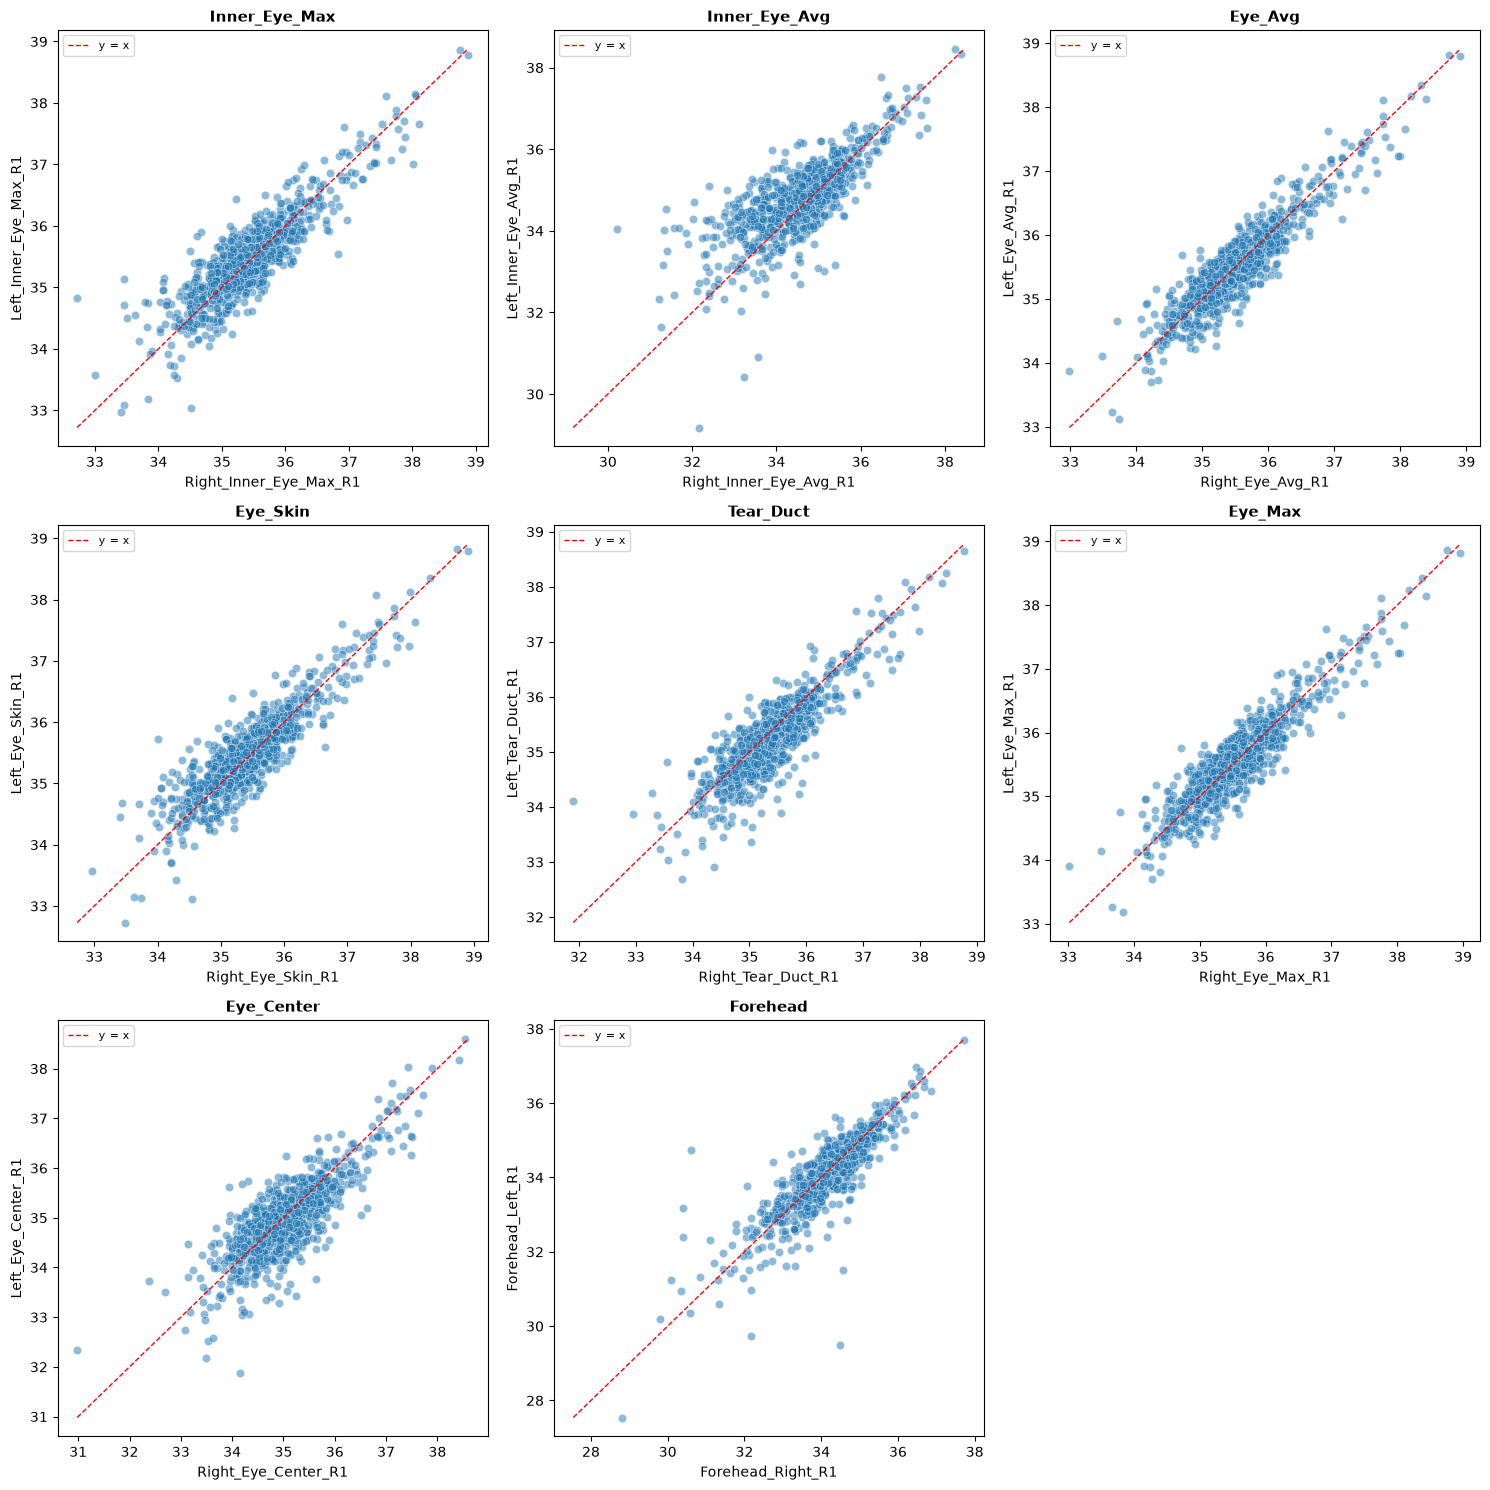

In [284]:
data = df[0].copy()

# Paired Right vs Left columns (symmetric measurements)
pairs = [
    ('Right_Inner_Eye_Max_R1', 'Left_Inner_Eye_Max_R1'),
    ('Right_Inner_Eye_Avg_R1', 'Left_Inner_Eye_Avg_R1'),
    ('Right_Eye_Avg_R1',       'Left_Eye_Avg_R1'),
    ('Right_Eye_Skin_R1',      'Left_Eye_Skin_R1'),
    ('Right_Tear_Duct_R1',     'Left_Tear_Duct_R1'),
    ('Right_Eye_Max_R1',       'Left_Eye_Max_R1'),
    ('Right_Eye_Center_R1',    'Left_Eye_Center_R1'),
    ('Forehead_Right_R1',      'Forehead_Left_R1'),
]

n_cols = 3
n_rows = -(-len(pairs) // n_cols)

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(15, 5 * n_rows)
)

axes = axes.flatten()

for ax, (right_col, left_col) in zip(axes, pairs):

    sns.scatterplot(
        data=data,
        x=right_col,
        y=left_col,
        alpha=0.5,
        ax=ax
    )

    # y = x reference line to visualize perfect symmetry
    lims = [
        min(data[right_col].min(), data[left_col].min()),
        max(data[right_col].max(), data[left_col].max())
    ]

    ax.plot(
        lims,
        lims,
        'r--',
        linewidth=1,
        label='y = x'
    )

    ax.set_title(
        right_col.replace('Right_', '').replace('_R1', ''),
        fontsize=11,
        fontweight='bold'
    )

    ax.set_xlabel(right_col)
    ax.set_ylabel(left_col)
    ax.legend(fontsize=8)

# Hide unused axes
for ax in axes[len(pairs):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

The right-side and left-side thermal measurements show strong positive relationships, with most observations lying close to the y = x reference line. This indicates that corresponding measurements from both sides of the face are generally similar, suggesting considerable redundancy among these features.

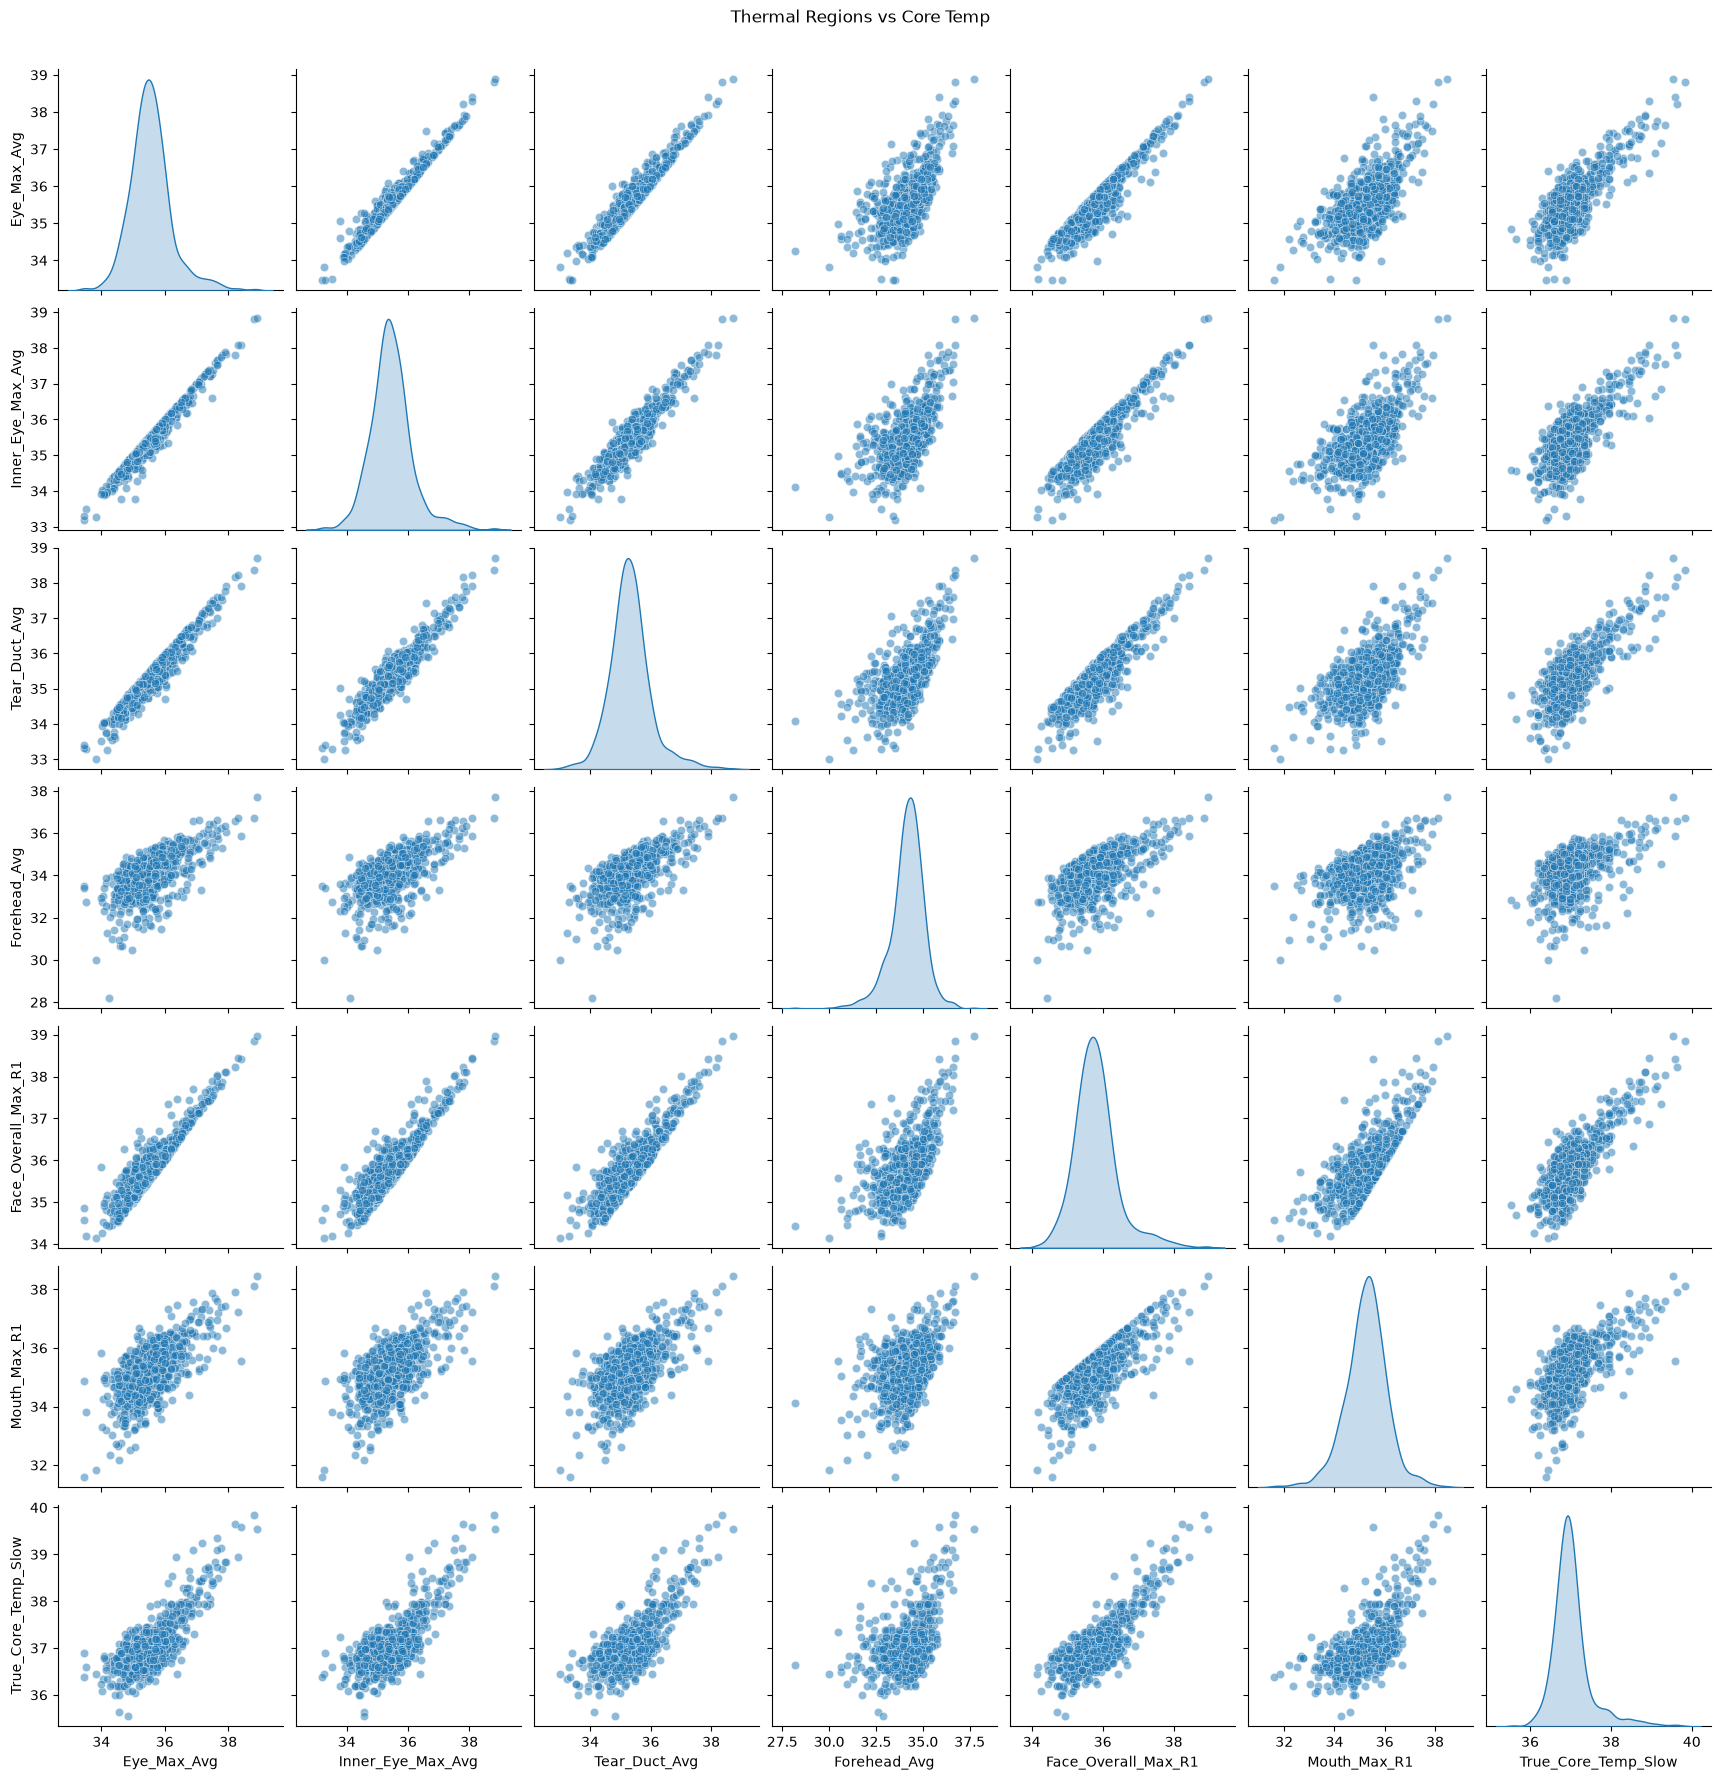

In [285]:
data_p = data.copy()

# Average left/right 
data_p['Eye_Max_Avg']       = data_p[['Right_Eye_Max_R1', 'Left_Eye_Max_R1']].mean(axis=1)
data_p['Inner_Eye_Max_Avg'] = data_p[['Right_Inner_Eye_Max_R1', 'Left_Inner_Eye_Max_R1']].mean(axis=1)
data_p['Tear_Duct_Avg']     = data_p[['Right_Tear_Duct_R1', 'Left_Tear_Duct_R1']].mean(axis=1)
data_p['Forehead_Avg']      = data_p[['Forehead_Right_R1', 'Forehead_Left_R1']].mean(axis=1)

cols = ['Eye_Max_Avg', 'Inner_Eye_Max_Avg', 'Tear_Duct_Avg', 'Forehead_Avg',
        'Face_Overall_Max_R1', 'Mouth_Max_R1', 'True_Core_Temp_Slow']

sns.pairplot(data_p[cols], kind='scatter', diag_kind='kde', plot_kws={'alpha': 0.5})
plt.suptitle("Thermal Regions vs Core Temp", y=1.02)
plt.show()

The forehead and mouth temperature features show comparatively lower correlations with the true core temperature, with more scattered relationships than the eye-region features.

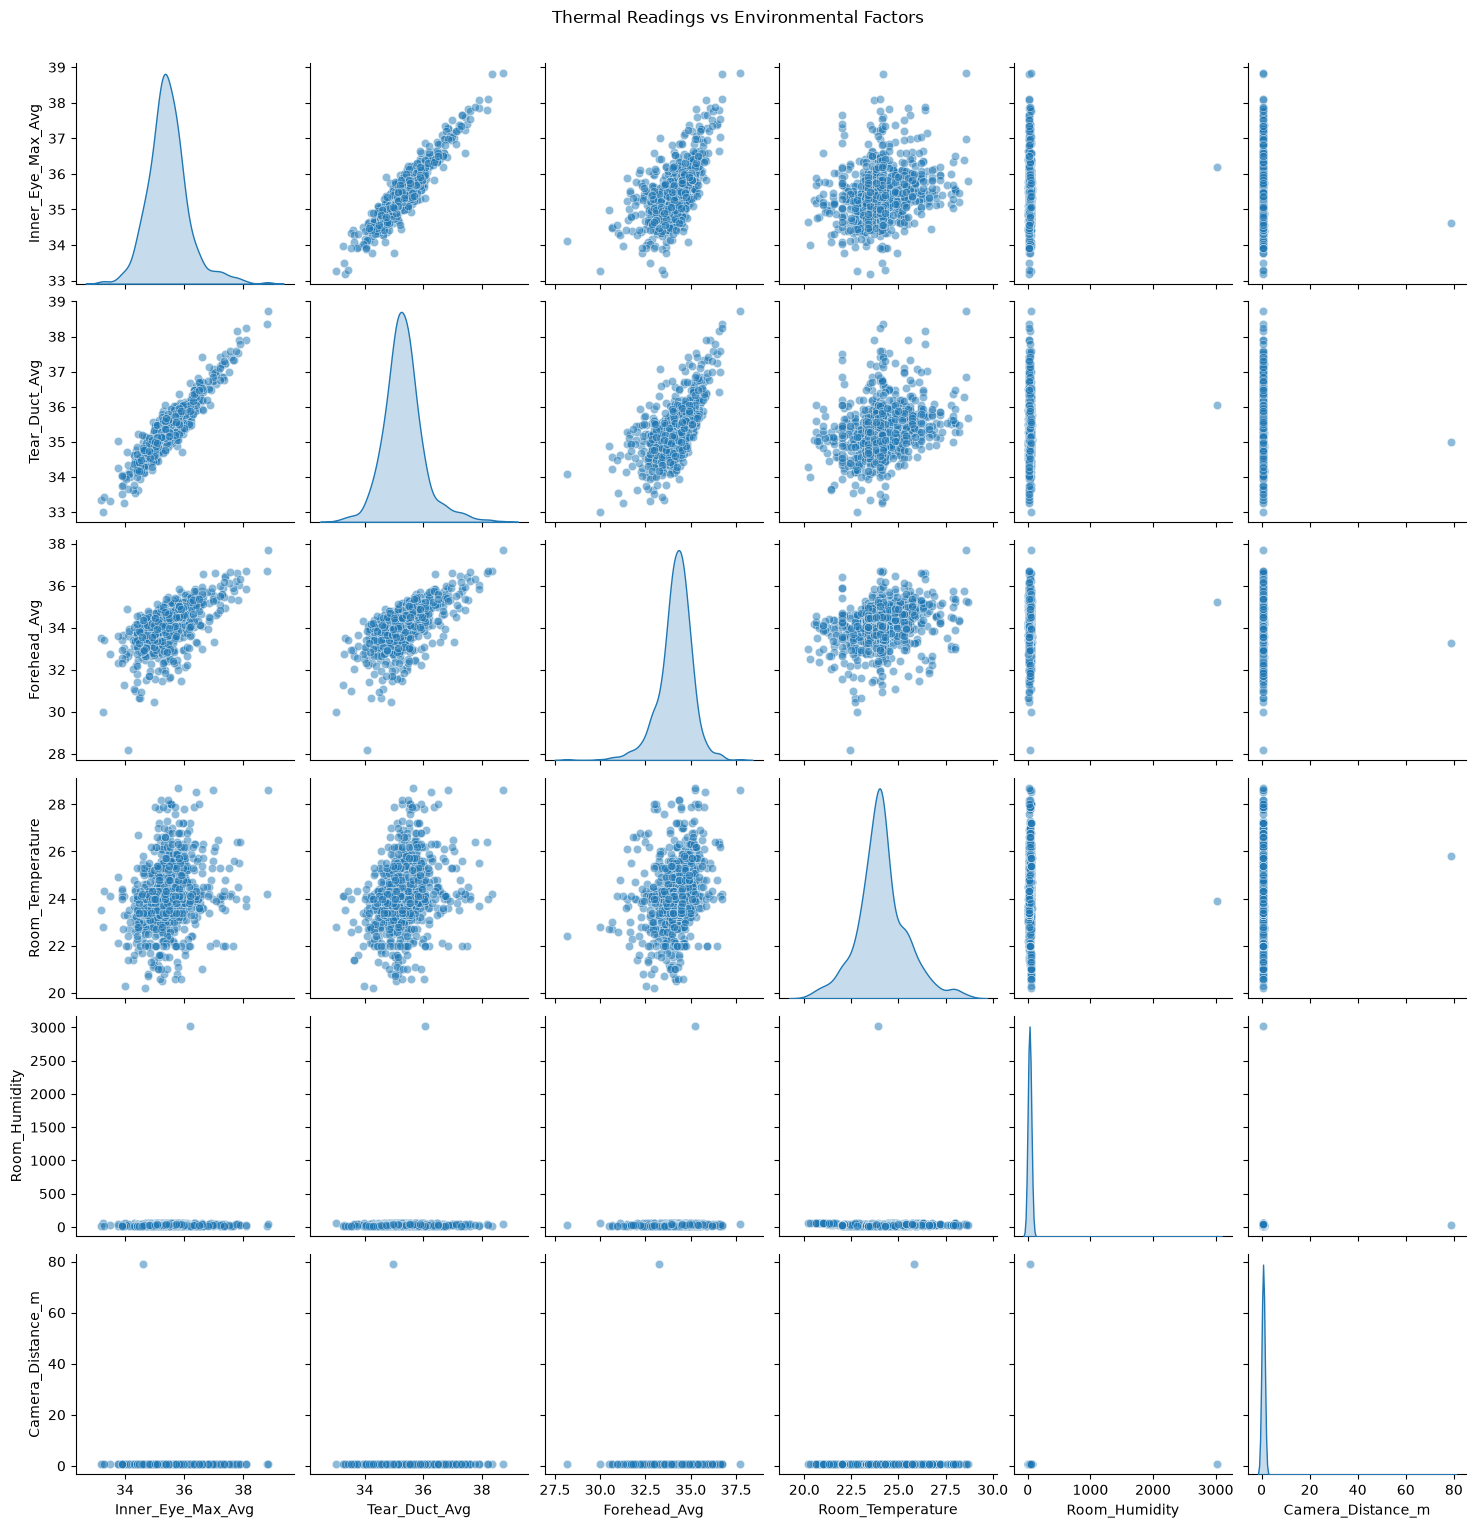

In [286]:
env_cols = ['Inner_Eye_Max_Avg', 'Tear_Duct_Avg', 'Forehead_Avg',
            'Room_Temperature', 'Room_Humidity', 'Camera_Distance_m']

sns.pairplot(data_p[env_cols], kind='scatter', diag_kind='kde', plot_kws={'alpha': 0.5})
plt.suptitle("Thermal Readings vs Environmental Factors", y=1.02)
plt.show()

The repeated horizontal and vertical patterns in the plots suggest that many observations were recorded under similar or repeated environmental conditions, particularly for room temperature, humidity, and camera distance.

Scatter plots which show feature Target Relationships

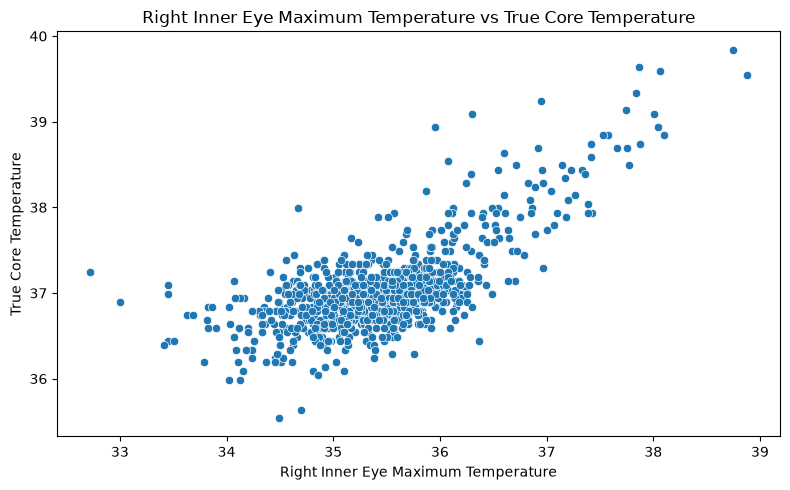

In [287]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=data,
    x='Right_Inner_Eye_Max_R1',
    y='True_Core_Temp_Slow'
)

plt.title("Right Inner Eye Maximum Temperature vs True Core Temperature")
plt.xlabel("Right Inner Eye Maximum Temperature")
plt.ylabel("True Core Temperature")

plt.tight_layout()
plt.show()

The relationship is positive, but there is still substantial scatter, especially around the main cluster. The feature has some predictive information, but it does not map cleanly to core temperature by itself.

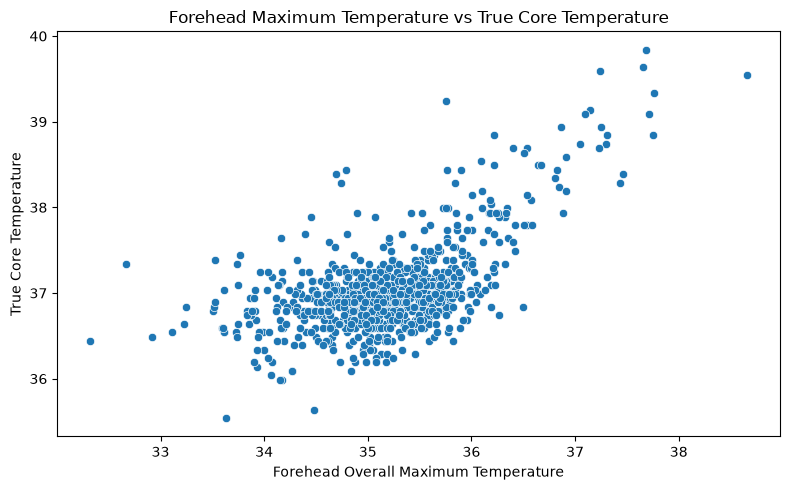

In [288]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=data,
    x='Forehead_Overall_Max_R1',
    y='True_Core_Temp_Slow'
)

plt.title("Forehead Maximum Temperature vs True Core Temperature")
plt.xlabel("Forehead Overall Maximum Temperature")
plt.ylabel("True Core Temperature")

plt.tight_layout()
plt.show()

The forehead temperature shows greater scatter and less consistent variation with the target, indicating that it is a relatively weaker predictor compared with the inner-eye temperature.

b) Heatmap

In [289]:
from sklearn.model_selection import GroupShuffleSplit

# Make copies of all 4 processed rounds
r1 = df[0].copy()
r2 = df[1].copy()
r3 = df[2].copy()
r4 = df[3].copy()

# Remove round suffixes
r1.columns = r1.columns.str.replace('_R1', '', regex=False)
r2.columns = r2.columns.str.replace('_R2', '', regex=False)
r3.columns = r3.columns.str.replace('_R3', '', regex=False)
r4.columns = r4.columns.str.replace('_R4', '', regex=False)

# Combine all rounds
full_data = pd.concat([r1, r2, r3, r4], ignore_index=True)

# Split by Subject_ID
gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(full_data, groups=full_data['Subject_ID'])
)

train_data = full_data.iloc[train_idx].copy()
test_data = full_data.iloc[test_idx].copy()

print("Full data:", full_data.shape)
print("Training:", train_data.shape)
print("Testing:", test_data.shape)
print("Training subjects:", train_data['Subject_ID'].nunique())
print("Testing subjects:", test_data['Subject_ID'].nunique())

Full data: (3474, 39)
Training: (2778, 39)
Testing: (696, 39)
Training subjects: 779
Testing subjects: 195


In [ ]:
# ==========================================
# Outlier filtering
# ==========================================

env_cols = [
    'Room_Temperature',
    'Room_Humidity',
    'Camera_Distance_m'
]

# ------------------------------------------
# 1. Fixed fever cutoff
# ------------------------------------------

train_data = train_data[
    train_data['True_Core_Temp_Slow'] <= 39.5
].copy()

test_data = test_data[
    test_data['True_Core_Temp_Slow'] <= 39.5
].copy()


# ------------------------------------------
# 2. Calculate IQR bounds from TRAIN only
# ------------------------------------------

iqr_bounds = {}

for col in env_cols:

    Q1 = train_data[col].quantile(0.25)
    Q3 = train_data[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    iqr_bounds[col] = (lower_bound, upper_bound)

    print(
        f"{col}: "
        f"{lower_bound:.2f} to {upper_bound:.2f}"
    )


# ------------------------------------------
# 3. Apply SAME bounds to train and test
# ------------------------------------------

for col, (lower_bound, upper_bound) in iqr_bounds.items():

    train_data = train_data[
        (train_data[col] >= lower_bound) &
        (train_data[col] <= upper_bound)
    ].copy()

    test_data = test_data[
        (test_data[col] >= lower_bound) &
        (test_data[col] <= upper_bound)
    ].copy()


print("\nAfter outlier filtering:")
print("Training shape:", train_data.shape)
print("Testing shape:", test_data.shape)

print("Training subjects:",
      train_data['Subject_ID'].nunique())

print("Testing subjects:",
      test_data['Subject_ID'].nunique())

Room_Temperature: 21.45 to 26.65
Room_Humidity: -9.57 to 61.82
Camera_Distance_m: 0.45 to 0.85

After outlier filtering:
Training shape: (2575, 39)
Testing shape: (628, 39)
Training subjects: 723
Testing subjects: 177


drop features based on correlation values

In [291]:
numerical_features = [
    'Calibration_Offset', 'Right_Inner_Eye_Max',
    'Left_Inner_Eye_Max', 'Right_Inner_Eye_Avg',
    'Left_Inner_Eye_Avg', 'Right_Eye_Avg',
    'Right_Eye_Skin', 'Right_Tear_Duct', 'Right_Eye_Max',
    'Left_Eye_Avg', 'Left_Eye_Skin', 'Left_Tear_Duct',
    'Left_Eye_Max', 'Right_Eye_Center', 'Left_Eye_Center',
    'Hottest_Eye_Overall', 'Hottest_Eye_4Points',
    'Forehead_Center', 'Forehead_Right', 'Forehead_Left',
    'Forehead_Bottom', 'Forehead_Top',
    'Forehead_Overall_Max', 'Forehead_Center_Max',
    'Face_Overall_Max', 'Mouth_Avg', 'Mouth_Max',
    'Room_Temperature', 'Room_Humidity', 'Camera_Distance_m'
]

threshold = 0.9


corr_matrix = train_data[numerical_features].corr().abs()

# Upper triangle
upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

# Find highly correlated features
to_drop = [
    col for col in upper_triangle.columns
    if any(upper_triangle[col] > threshold)
]

print(f"Features to drop ({len(to_drop)}):")
print(to_drop)

# Drop the same features from both datasets
train_data = train_data.drop(columns=to_drop)
test_data = test_data.drop(columns=to_drop)

print(f"\nTraining features remaining: {train_data.shape[1]}")
print(f"Testing features remaining: {test_data.shape[1]}")
print("\nRemaining columns:")
for i, col in enumerate(train_data.columns, 1):
    print(f"{i}. {col}")


Features to drop (15):
['Right_Eye_Avg', 'Right_Eye_Skin', 'Right_Tear_Duct', 'Right_Eye_Max', 'Left_Eye_Avg', 'Left_Eye_Skin', 'Left_Tear_Duct', 'Left_Eye_Max', 'Right_Eye_Center', 'Left_Eye_Center', 'Hottest_Eye_Overall', 'Hottest_Eye_4Points', 'Forehead_Bottom', 'Forehead_Center_Max', 'Mouth_Max']

Training features remaining: 24
Testing features remaining: 24

Remaining columns:
1. Subject_ID
2. Calibration_Offset
3. Right_Inner_Eye_Max
4. Left_Inner_Eye_Max
5. Right_Inner_Eye_Avg
6. Left_Inner_Eye_Avg
7. Forehead_Center
8. Forehead_Right
9. Forehead_Left
10. Forehead_Top
11. Forehead_Overall_Max
12. Face_Overall_Max
13. Mouth_Avg
14. True_Core_Temp_Fast
15. True_Core_Temp_Slow
16. Gender
17. Age
18. Ethnicity
19. Room_Temperature
20. Room_Humidity
21. Camera_Distance_m
22. Wearing_Makeup
23. Time
24. Date


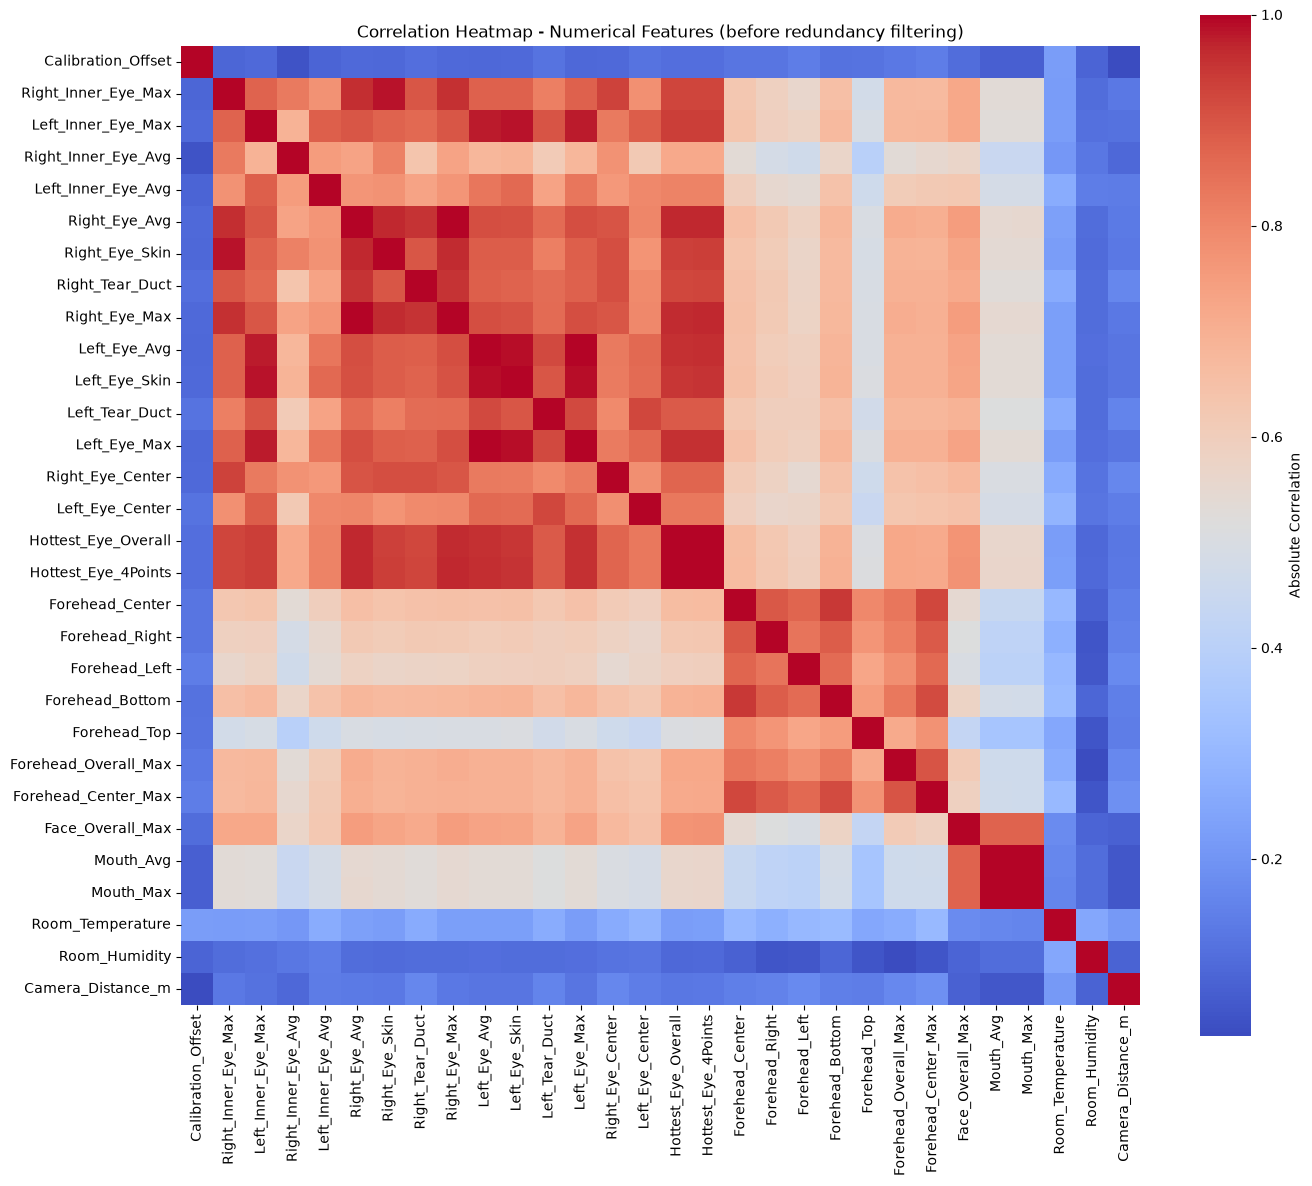

In [292]:
plt.figure(figsize=(14, 12))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=False, square=True,
            cbar_kws={'label': 'Absolute Correlation'})
plt.title("Correlation Heatmap - Numerical Features (before redundancy filtering)")
plt.tight_layout()
plt.show()

The heatmap shows strong correlations among the eye-region features and moderate-to-strong correlations among the forehead features, indicating considerable redundancy. In contrast, the environmental features have relatively weak correlations with the thermal measurements. Therefore, highly correlated features can be filtered to reduce redundancy and multicollinearity before model development.

PC1 explains 48.87% of variance
Correlation between PC1 and True Core Temp (Slow): 0.681


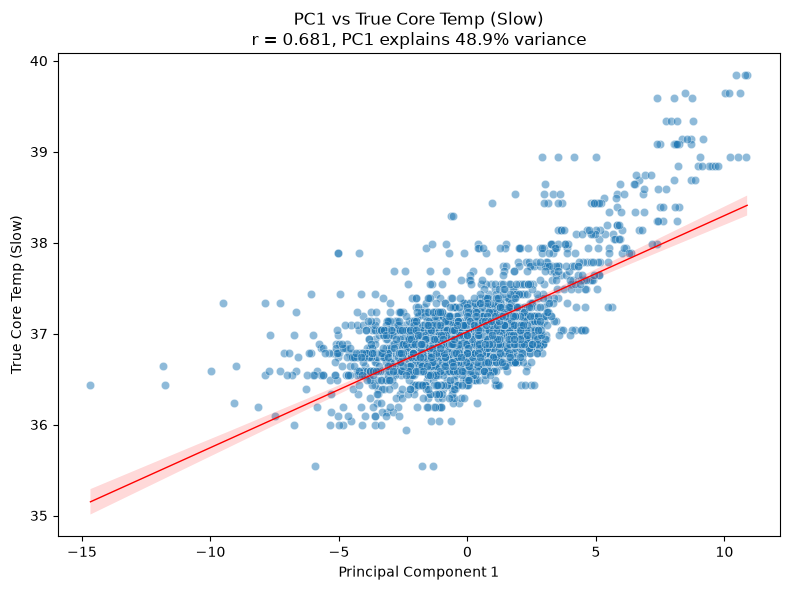

In [293]:

data = train_data.copy()

feature_cols = [
    'Calibration_Offset',
    'Right_Inner_Eye_Max',
    'Left_Inner_Eye_Max',
    'Right_Inner_Eye_Avg',
    'Left_Inner_Eye_Avg',
    'Forehead_Center',
    'Forehead_Right',
    'Forehead_Left',
    'Forehead_Top',
    'Forehead_Overall_Max',
    'Mouth_Avg',
    'Room_Temperature',
    'Room_Humidity',
    'Camera_Distance_m',
    
]

X = data[feature_cols].dropna()

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fit PCA
pca = PCA()
pca_result = pca.fit_transform(X_scaled)

# Add PC1 to corresponding rows
data_pca = data.loc[X.index].copy()
data_pca['PC1'] = pca_result[:, 0]

# Variance explained by PC1
pc1_variance = pca.explained_variance_ratio_[0] * 100

print(f"PC1 explains {pc1_variance:.2f}% of variance")

# Correlation between PC1 and Slow Core Temperature
corr = data_pca['PC1'].corr(
    data_pca['True_Core_Temp_Slow']
)

print(f"Correlation between PC1 and True Core Temp (Slow): {corr:.3f}")

# Plot PC1 vs Slow Core Temperature
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=data_pca,
    x='PC1',
    y='True_Core_Temp_Slow',
    alpha=0.5
)

sns.regplot(
    data=data_pca,
    x='PC1',
    y='True_Core_Temp_Slow',
    scatter=False,
    color='red',
    line_kws={'linewidth': 1}
)

plt.title(
    f"PC1 vs True Core Temp (Slow)\n"
    f"r = {corr:.3f}, "
    f"PC1 explains {pc1_variance:.1f}% variance"
)

plt.xlabel("Principal Component 1")
plt.ylabel("True Core Temp (Slow)")

plt.tight_layout()
plt.show()

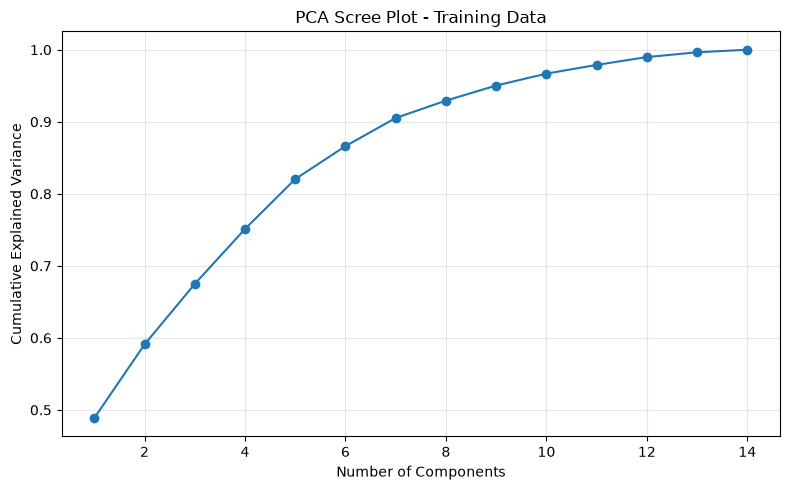

In [294]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(pca.explained_variance_ratio_) + 1),
    np.cumsum(pca.explained_variance_ratio_),
    marker='o'
)

plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Scree Plot - Training Data")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

The scree plot shows that a large number of principal components are required to retain most of the variance, with around 10 components needed to capture approximately 97% of the variance. Since PCA would transform the original features into less interpretable components while still requiring many components, we avoid PCA and retain the original features for better interpretability in the regression models.

In [295]:
# Training and testing data were split by Subject_ID
# using an 80/20 GroupShuffleSplit

feature_cols = [
    'Calibration_Offset',
    'Right_Inner_Eye_Max',
    'Left_Inner_Eye_Max',
    'Right_Inner_Eye_Avg',
    'Left_Inner_Eye_Avg',
    'Forehead_Center',
    'Forehead_Right',
    'Forehead_Left',
    'Forehead_Top',
    'Forehead_Overall_Max',
    'Mouth_Avg',
    'Room_Temperature',
    'Room_Humidity',
    'Camera_Distance_m',
    'Gender',
    'Ethnicity',
    'Wearing_Makeup'
]

target_col = 'True_Core_Temp_Slow'

# --------------------------------------------------
# Keep Subject_ID separately for GroupKFold
# --------------------------------------------------
train_groups = train_data['Subject_ID'].copy()

# Keep only features and target
train_model_data = train_data[feature_cols + [target_col]].copy()
test_model_data = test_data[feature_cols + [target_col]].copy()

# Remove rows containing missing values
train_valid = train_model_data.notna().all(axis=1)
test_valid = test_model_data.notna().all(axis=1)

train_model_data = train_model_data[train_valid].copy()
test_model_data = test_model_data[test_valid].copy()

# Keep groups aligned with training rows
train_groups = train_groups.loc[train_model_data.index]

# Separate features and target
X_train = train_model_data[feature_cols]
y_train = train_model_data[target_col]

X_test = test_model_data[feature_cols]
y_test = test_model_data[target_col]

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")
print(f"Training subjects: {train_groups.nunique()}")

# Numerical columns
numerical_cols = [
    'Calibration_Offset',
    'Right_Inner_Eye_Max',
    'Left_Inner_Eye_Max',
    'Right_Inner_Eye_Avg',
    'Left_Inner_Eye_Avg',
    'Forehead_Center',
    'Forehead_Right',
    'Forehead_Left',
    'Forehead_Top',
    'Forehead_Overall_Max',
    'Mouth_Avg',
    'Room_Temperature',
    'Room_Humidity',
    'Camera_Distance_m'
]

# Categorical columns
categorical_cols = [
    'Gender',
    'Ethnicity',
    'Wearing_Makeup'
]

# Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(
            drop='first',
            handle_unknown='ignore'
        ), categorical_cols)
    ]
)

# Fit ONLY on training data
X_train_processed = preprocessor.fit_transform(X_train)

# Transform test data
X_test_processed = preprocessor.transform(X_test)

# Names of processed features
encoded_feature_names = preprocessor.get_feature_names_out()

print("Training shape:", X_train_processed.shape)
print("Testing shape:", X_test_processed.shape)
print("Number of processed features:", len(encoded_feature_names))

Training samples: 2575
Testing samples: 628
Training subjects: 723
Training shape: (2575, 21)
Testing shape: (628, 21)
Number of processed features: 21


Numerical features are standardized to bring them to a common scale, while categorical features are one-hot encoded to convert them into suitable numerical representations without imposing any artificial order.

## Regression Models

### 1. Linear Regression

In [296]:
linear_model = LinearRegression()

linear_model.fit(X_train_processed, y_train)

y_pred_linear = linear_model.predict(X_test_processed)


### 2. Ridge Regression

In [297]:
# ==========================================
# 2. Ridge Regression
# ==========================================

ridge_param_grid = {
    'alpha': [0.01, 0.1, 1.0, 10.0, 50.0, 100.0]
}

ridge_grid = GridSearchCV(
    Ridge(),
    ridge_param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

ridge_grid.fit(X_train_processed, y_train)

print("Best Ridge alpha:", ridge_grid.best_params_)
print("Best CV R²:", ridge_grid.best_score_)

# Use the best Ridge model
ridge_model = ridge_grid.best_estimator_

# Train on complete training data
ridge_model.fit(X_train_processed, y_train)

# Predict test data
y_pred_ridge = ridge_model.predict(X_test_processed)

print("Ridge Test R²:", r2_score(y_test, y_pred_ridge))

Best Ridge alpha: {'alpha': 0.1}
Best CV R²: 0.6143401837566411
Ridge Test R²: 0.6532040946867808


In [298]:
# Ridge before tuning
ridge_default = Ridge()
ridge_default.fit(X_train_processed, y_train)

ridge_before = r2_score(
    y_test,
    ridge_default.predict(X_test_processed)
)

ridge_after = r2_score(
    y_test,
    ridge_grid.predict(X_test_processed)
)

print("Ridge R² before tuning:", ridge_before)
print("Ridge R² after tuning:", ridge_after)
print("Ridge improvement:", ridge_after - ridge_before)

Ridge R² before tuning: 0.6533148920597969
Ridge R² after tuning: 0.6532040946867808
Ridge improvement: -0.00011079737301611381


### 3. Lasso Regression

In [299]:
lasso_model = Lasso(alpha=0.01, max_iter=10000)

lasso_model.fit(X_train_processed, y_train)

y_pred_lasso = lasso_model.predict(X_test_processed)

### 4. ElasticNet Regression

In [300]:
elastic_model = ElasticNet(
    alpha=0.01,
    l1_ratio=0.5,
    max_iter=10000,
    random_state=42
)

elastic_model.fit(X_train_processed, y_train)

y_pred_elastic = elastic_model.predict(X_test_processed)



### 5. Polynomial Regression

In [301]:
poly_scores = {}
for degree in [2, 3]:
    poly_pipeline = Pipeline([
        ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
        ('linear', LinearRegression())
    ])
    poly_pipeline.fit(X_train_processed, y_train)
    poly_pred = poly_pipeline.predict(X_test_processed)
    poly_scores[degree] = r2_score(y_test, poly_pred)
    print(f"Degree {degree}: R2 = {poly_scores[degree]:.4f}")

best_degree = max(poly_scores, key=poly_scores.get)
print(f"\nBest polynomial degree: {best_degree}")

polynomial_model = Pipeline([
    ('poly', PolynomialFeatures(degree=best_degree, include_bias=False)),
    ('linear', LinearRegression())
])
polynomial_model.fit(X_train_processed, y_train)
y_pred_polynomial = polynomial_model.predict(X_test_processed)

Degree 2: R2 = 0.6636
Degree 3: R2 = -2.6841

Best polynomial degree: 2


### 6. Decision Tree Regression

In [302]:
tree_model = DecisionTreeRegressor(
    max_depth=10,
    random_state=42
)

tree_model.fit(X_train_processed, y_train)

y_pred_tree = tree_model.predict(X_test_processed)


### 7. Random Forest Regression

In [303]:
rf_param_grid = {
    'n_estimators': [100, 300, 500],
    'max_depth': [5, 10, 15, None]
}

rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    rf_param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

rf_grid.fit(X_train_processed, y_train)

print("Best RF params:", rf_grid.best_params_)
print("Best CV R2:", rf_grid.best_score_)

rf_model = rf_grid.best_estimator_

rf_model.fit(X_train_processed, y_train)

y_pred_rf = rf_model.predict(X_test_processed)

print("Test R2 with tuned params:", r2_score(y_test, y_pred_rf))



Best RF params: {'max_depth': None, 'n_estimators': 500}
Best CV R2: 0.8009269015902755
Test R2 with tuned params: 0.6774332807774284


In [304]:
rf_before = RandomForestRegressor(random_state=42, n_jobs=-1)
rf_before.fit(X_train_processed, y_train)

rf_r2_before = r2_score(
    y_test,
    rf_before.predict(X_test_processed)
)

rf_r2_after = r2_score(
    y_test,
    rf_model.predict(X_test_processed)
)

rf_improvement = rf_r2_after - rf_r2_before

print("Random Forest R² before tuning:", rf_r2_before)
print("Random Forest R² after tuning:", rf_r2_after)
print("Random Forest improvement:", rf_improvement)

Random Forest R² before tuning: 0.6756136448682372
Random Forest R² after tuning: 0.6774332807774281
Random Forest improvement: 0.0018196359091909864


### 8. Gradient Boosting Regression

In [305]:
gb_model = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb_model.fit(X_train_processed, y_train)

y_pred_gb = gb_model.predict(X_test_processed)



### 9. Support Vector Regression (SVR)

In [306]:
svr_model = SVR(
    C=10,
    kernel='rbf',
    gamma='scale'
)

svr_model.fit(X_train_processed, y_train)

y_pred_svr = svr_model.predict(X_test_processed)


### 10. K-Nearest Neighbors (KNN) Regression

In [307]:
knn_model = KNeighborsRegressor(
    n_neighbors=5
)

knn_model.fit(X_train_processed, y_train)

y_pred_knn = knn_model.predict(X_test_processed)


## Analysis 

In [308]:
results = []
predictions = {
    "Linear Regression": y_pred_linear,
    "Ridge Regression": y_pred_ridge,
    "Lasso Regression": y_pred_lasso,
    "ElasticNet Regression": y_pred_elastic,
    "Polynomial Regression": y_pred_polynomial,
    "Decision Tree Regressor": y_pred_tree,
    "Random Forest Regressor": y_pred_rf,
    "Gradient Boosting Regressor": y_pred_gb,
    "Support Vector Regressor (SVR)": y_pred_svr,
    "K-Nearest Neighbors Regressor": y_pred_knn
}

for model_name, y_pred in predictions.items():

    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)

    results.append({
        "Model": model_name,
        "R2": r2,
        "RMSE": rmse,
        "MAE": mae
    })

results_df = pd.DataFrame(results)

# Rank models by R²
results_df = results_df.sort_values(
    by="R2",
    ascending=False
).reset_index(drop=True)

# Add ranking
results_df.insert(
    0,
    "Rank",
    range(1, len(results_df) + 1)
)

results_df

,Rank,Model,R2,RMSE,MAE
0,1,Gradient Boosting Regressor,0.679223,0.294928,0.225397
1,2,Random Forest Regressor,0.677433,0.295750,0.231908
2,3,Polynomial Regression,0.663576,0.302035,0.231113
3,4,ElasticNet Regression,0.653825,0.306381,0.242554
4,5,Ridge Regression,0.653204,0.306656,0.243452
5,6,Linear Regression,0.653189,0.306663,0.243461
6,7,Lasso Regression,0.644361,0.310541,0.245945
7,8,Support Vector Regressor (SVR),0.586460,0.334868,0.257719
8,9,Decision Tree Regressor,0.551656,0.348675,0.264915
9,10,K-Nearest Neighbors Regressor,0.550183,0.349247,0.264459


### 5-Fold Cross-Validation of Top 2 Models

In [309]:
# ==========================================
# Model Lookup for Cross-Validation
# ==========================================

model_lookup = {
    "Linear Regression": (linear_model, X_train_processed),
    "Ridge Regression": (ridge_model, X_train_processed),
    "Lasso Regression": (lasso_model, X_train_processed),
    "ElasticNet Regression": (elastic_model, X_train_processed),
    "Polynomial Regression": (polynomial_model, X_train_processed),
    "Decision Tree Regressor": (tree_model, X_train_processed),
    "Random Forest Regressor": (rf_model, X_train_processed),
    "Gradient Boosting Regressor": (gb_model, X_train_processed),
    "Support Vector Regressor (SVR)": (svr_model, X_train_processed),
    "K-Nearest Neighbors Regressor": (knn_model, X_train_processed)
}

group_kf = GroupKFold(n_splits=5)

cv_results = []

for name, model_info in model_lookup.items():

    model_obj, X_for_model = model_info

    cv_scores = cross_val_score(
        model_obj,
        X_for_model,
        y_train,
        cv=group_kf,
        groups=train_groups,
        scoring='r2',
        n_jobs=-1
    )

    cv_results.append({
        "Model": name,
        "Mean Group CV R²": cv_scores.mean()
    })

cv_results_df = pd.DataFrame(cv_results)

cv_results_df = cv_results_df.sort_values(
    by="Mean Group CV R²",
    ascending=False
).reset_index(drop=True)

cv_results_df

,Model,Mean Group CV R²
0,Gradient Boosting Regressor,0.677846
1,Random Forest Regressor,0.674807
2,Ridge Regression,0.610067
3,Linear Regression,0.610049
4,ElasticNet Regression,0.606731
5,Lasso Regression,0.598796
6,Polynomial Regression,0.592796
7,K-Nearest Neighbors Regressor,0.578043
8,Support Vector Regressor (SVR),0.560552
9,Decision Tree Regressor,0.473620


In [310]:
best_model_name = results_df.loc[0, "Model"]

print("Best model based on R²:")
print(best_model_name)

print("\nBest model performance:")
print(results_df.iloc[0])

Best model based on R²:
Gradient Boosting Regressor

Best model performance:
Rank                               1
Model    Gradient Boosting Regressor
R2                          0.679223
RMSE                        0.294928
MAE                         0.225397
Name: 0, dtype: object


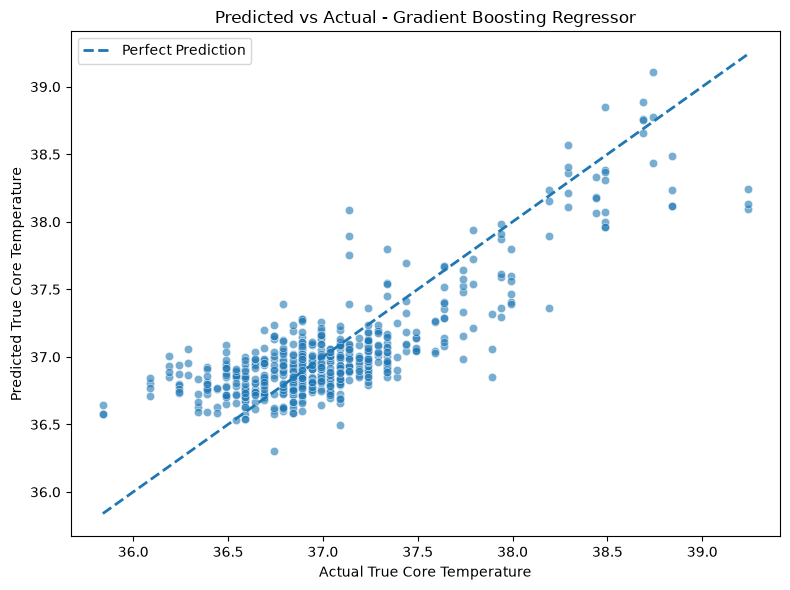

In [311]:
best_predictions = predictions[best_model_name]

plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=y_test,
    y=best_predictions,
    alpha=0.6
)

# Perfect prediction line
min_value = min(y_test.min(), best_predictions.min())
max_value = max(y_test.max(), best_predictions.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle='--',
    linewidth=2,
    label='Perfect Prediction'
)

plt.xlabel("Actual True Core Temperature")
plt.ylabel("Predicted True Core Temperature")

plt.title(
    f"Predicted vs Actual - {best_model_name}"
)

plt.legend()
plt.tight_layout()
plt.show()

The KNN model's predictions generally follow the actual core-temperature values, showing that the model captures the overall relationship with the target. However, several observations deviate from the perfect-prediction line, particularly at higher temperatures, indicating that the model has difficulty accurately predicting some extreme values.

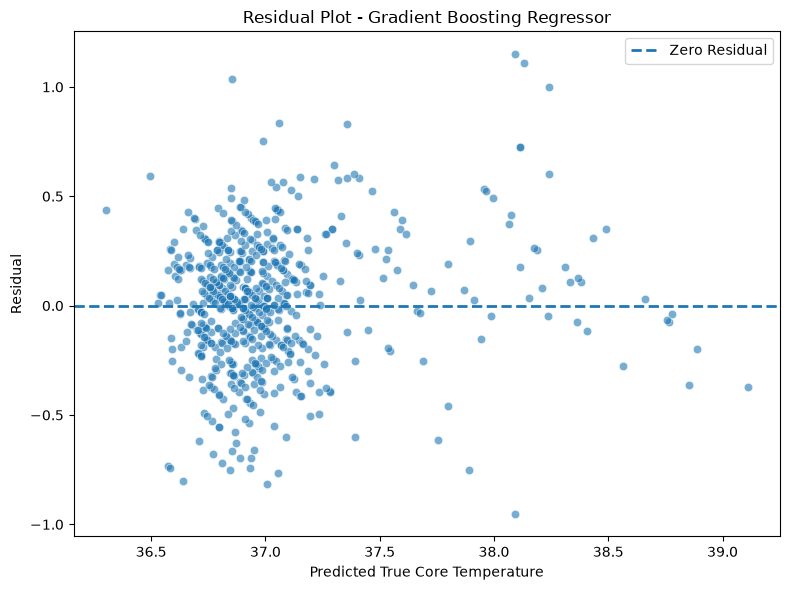

In [312]:
residuals = y_test - best_predictions

plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=best_predictions,
    y=residuals,
    alpha=0.6
)

plt.axhline(
    y=0,
    linestyle='--',
    linewidth=2,
    label='Zero Residual'
)

plt.xlabel("Predicted True Core Temperature")
plt.ylabel("Residual")

plt.title(
    f"Residual Plot - {best_model_name}"
)

plt.legend()
plt.tight_layout()
plt.show()

The residuals are mostly distributed around the zero-residual line, indicating that the KNN model produces both overpredictions and underpredictions. However, some larger residuals are present, particularly at higher predicted temperatures, showing that the model has greater prediction error for some observations.

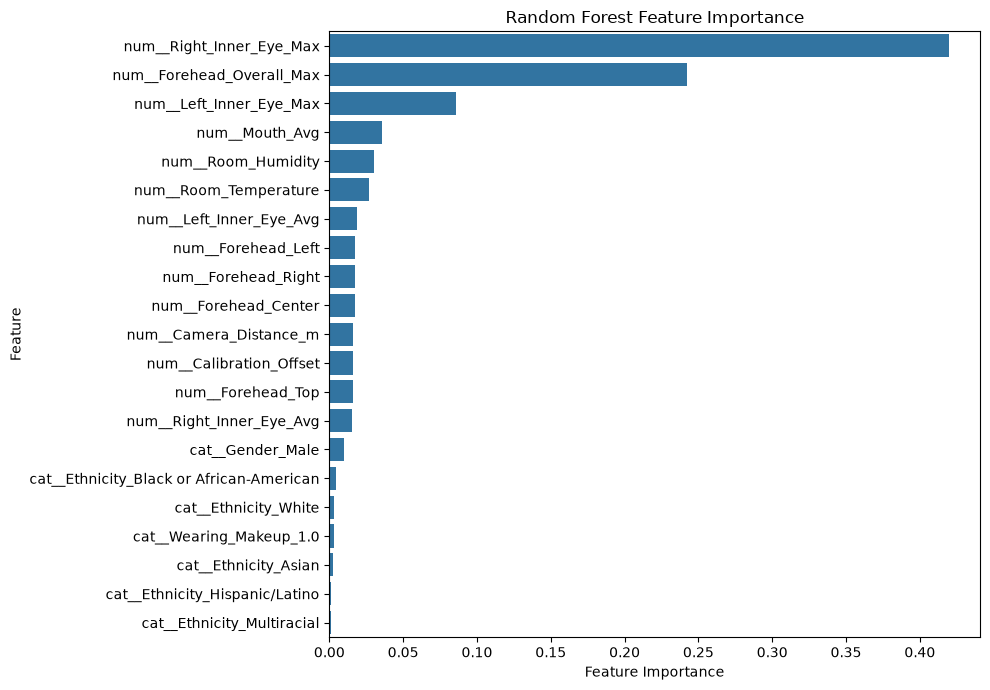

In [313]:
feature_importance = pd.DataFrame({
    "Feature": encoded_feature_names,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

The Random Forest feature-importance plot shows that Right_Inner_Eye_Max contributes the most to the model's predictions, followed by Forehead_Overall_Max, Left_Inner_Eye_Max, and Mouth_Avg. In comparison, the categorical features and some environmental features have very low importance, indicating that the model relies mainly on the facial thermal measurements for prediction.

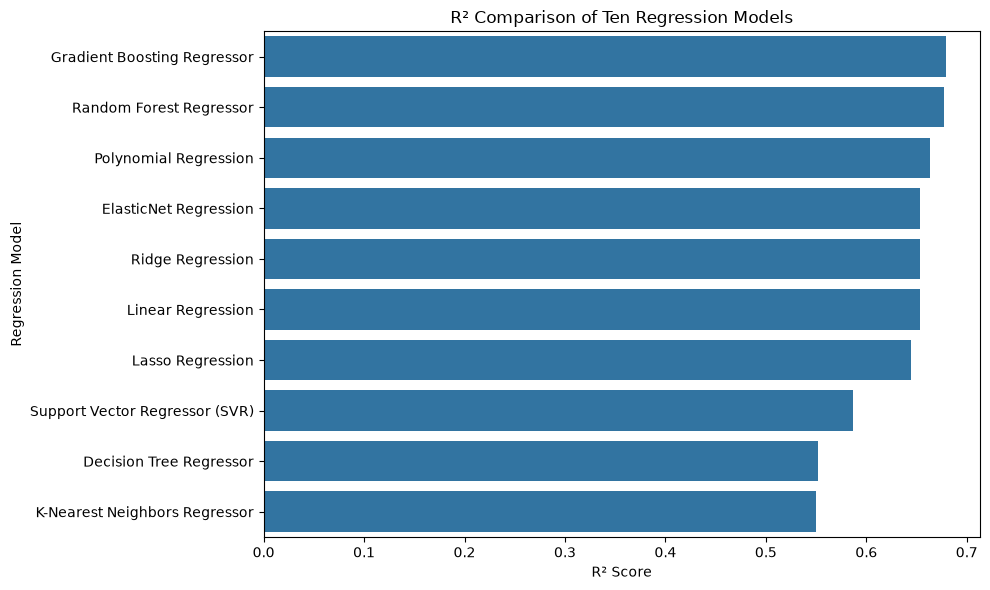

In [314]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=results_df,
    x="R2",
    y="Model"
)

plt.xlabel("R² Score")
plt.ylabel("Regression Model")
plt.title("R² Comparison of Ten Regression Models")

plt.tight_layout()
plt.show()

### Effect of the Engineered feature across models